WILSON DISSERTATION — MASTER ANALYSIS SCRIPT
MSc Business Analytics and Technology — University of Bolton
Student: Agene Osemegbe Wilson | ID: 2434966
Title: Predictive Analytics for Motor Insurance Risk

In [6]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

!pip install streamlit pyngrok pmdarima -q
!streamlit run Wilson_Dashboard_Streamlit.py &
from pyngrok import ngrok


Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: Wilson_Dashboard_Streamlit.py


In [7]:
# Chart styling — white background, serif font for academic look
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.family']      = 'serif'

In [8]:
COLLISION_FILE = 'dft-road-casualty-statistics-collision-last-5-years.csv'
FUEL_FILE      = 'weekly_road_fuel_prices_230226.csv'

In [9]:

print("SECTION 1 — IMPORTS AND FILE PATHS")
print("=" * 50)
for fname in [COLLISION_FILE, FUEL_FILE]:
    exists = "Found" if os.path.exists(fname) else "❌ NOT FOUND — check filename"
    print(f"  {exists}: {fname}")

print(f"\n Section 1 complete — all tools loaded.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

SECTION 1 — IMPORTS AND FILE PATHS
  Found: dft-road-casualty-statistics-collision-last-5-years.csv
  Found: weekly_road_fuel_prices_230226.csv

 Section 1 complete — all tools loaded.
   pandas  : 2.2.2
   numpy   : 2.0.2


In [10]:
print("SECTION 2 — LOAD COLLISION DATA")
print("=" * 50)


df_raw = pd.read_csv(COLLISION_FILE, low_memory=False)

print(f"\n Section 2 complete.")
print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")

SECTION 2 — LOAD COLLISION DATA

 Section 2 complete.
   Rows    : 503,475
   Columns : 44


In [11]:
print("SECTION 3 — DATE PARSING AND FILTERING")
print("=" * 50)

# Parse date column using confirmed DD/MM/YYYY format
df_raw['date'] = pd.to_datetime(df_raw['date'], format='%d/%m/%Y', errors='coerce')

# Filter using collision_year (most reliable column — already clean integers)
df = df_raw[df_raw['collision_year'].isin([2020, 2021, 2022, 2023, 2024])].copy()

# Time columns
df['year']      = df['collision_year'].astype(int)
df['month']     = df['date'].dt.month
df['yearmonth'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
df['yearmonth'] = df['yearmonth'].apply(lambda x: pd.Period(x, freq='M'))

# Day of week labels (STATS19: 1=Monday, 7=Sunday)
dow_map = {1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday',
           5:'Friday', 6:'Saturday', 7:'Sunday'}
df['day_name']   = df['day_of_week'].map(dow_map)
df['is_weekend'] = df['day_of_week'].isin([1, 7]).astype(int)

# Severity labels
df['severity_label'] = df['collision_severity'].map(
    {1:'Fatal', 2:'Serious', 3:'Slight'})

# Weather labels
df['weather_label'] = df['weather_conditions'].map({
    1:'Fine — no wind',      2:'Raining — no wind',
    3:'Snowing — no wind',   4:'Fine — high wind',
    5:'Raining — high wind', 6:'Snowing — high wind',
    7:'Fog or mist',         8:'Other', 9:'Unknown'})

# Road surface labels
df['surface_label'] = df['road_surface_conditions'].map({
    1:'Dry', 2:'Wet or damp', 3:'Snow',
    4:'Frost or ice', 5:'Flood water',
    6:'Oil or diesel', 7:'Mud', 9:'Unknown'})

# Light condition labels
df['light_label'] = df['light_conditions'].map({
    1:'Daylight',            4:'Darkness — lit',
    5:'Darkness — unlit',    6:'Darkness — no lighting',
    7:'Darkness — unknown lighting'})

# Urban/Rural labels
df['urban_label'] = df['urban_or_rural_area'].map(
    {1:'Urban', 2:'Rural', 3:'Unallocated'})

print(f"\nSection 3 complete.")
print(f"   Total rows : {len(df):,}  (should be 503,475)")
print(f"\n   Year breakdown:")
for yr, cnt in df['collision_year'].value_counts().sort_index().items():
    bar = '█' * int(cnt / 3000)
    print(f"   {yr}: {cnt:>7,}  {bar}")

SECTION 3 — DATE PARSING AND FILTERING

Section 3 complete.
   Total rows : 503,475  (should be 503,475)

   Year breakdown:
   2020:  91,199  ██████████████████████████████
   2021: 101,087  █████████████████████████████████
   2022: 106,004  ███████████████████████████████████
   2023: 104,258  ██████████████████████████████████
   2024: 100,927  █████████████████████████████████


In [12]:
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,year,month,yearmonth,day_name,is_weekend,severity_label,weather_label,surface_label,light_label,urban_label
0,2021170H10421,2021,170H10421,447098.0,532997.0,-1.270905,54.689833,17,3,2,...,2021,5,2021-05,Sunday,1,Slight,Fine — no wind,Dry,Darkness — no lighting,Rural
1,2021170H11231,2021,170H11231,450486.0,533118.0,-1.218333,54.690592,17,3,2,...,2021,10,2021-10,Thursday,0,Slight,Fine — no wind,Dry,Daylight,Urban
2,2020170M11750,2020,170M11750,449694.0,519733.0,-1.232884,54.570397,17,3,2,...,2020,12,2020-12,Wednesday,0,Slight,Fine — no wind,Dry,Darkness — lit,Urban
3,2021170M31761,2021,170M31761,449744.0,514217.0,-1.233040,54.520825,17,3,1,...,2021,12,2021-12,Friday,0,Slight,Fine — no wind,Wet or damp,Darkness — lit,Rural
4,2021170S10441,2021,170S10441,445971.0,520834.0,-1.290292,54.580641,17,3,3,...,2021,4,2021-04,Tuesday,0,Slight,Fine — no wind,Dry,Daylight,Rural


In [13]:
df.index

RangeIndex(start=0, stop=503475, step=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 54 columns):
 #   Column                                            Non-Null Count   Dtype         
---  ------                                            --------------   -----         
 0   collision_index                                   503475 non-null  object        
 1   collision_year                                    503475 non-null  int64         
 2   collision_ref_no                                  503475 non-null  object        
 3   location_easting_osgr                             503410 non-null  float64       
 4   location_northing_osgr                            503410 non-null  float64       
 5   longitude                                         503410 non-null  float64       
 6   latitude                                          503410 non-null  float64       
 7   police_force                                      503475 non-null  int64         
 8   collision_seve

In [15]:
key_cols = [
    'date', 'collision_severity', 'number_of_casualties',
    'number_of_vehicles', 'weather_conditions',
    'road_surface_conditions', 'light_conditions',
    'speed_limit', 'urban_or_rural_area', 'day_of_week'
]

In [16]:
print(f"\n  {'Column':<38} {'Missing':>8}  {'%':>6}  Status")
print("  " + "-" * 60)
for col in key_cols:
    if col in df.columns:
        n   = df[col].isnull().sum()
        pct = n / len(df) * 100
        flag = "OK" if pct < 5 else "Check" if pct < 20 else "High"
        print(f"  {col:<38} {n:>8,}  {pct:>5.2f}%  {flag}")



  Column                                  Missing       %  Status
  ------------------------------------------------------------
  date                                          0   0.00%  OK
  collision_severity                            0   0.00%  OK
  number_of_casualties                          0   0.00%  OK
  number_of_vehicles                            0   0.00%  OK
  weather_conditions                            0   0.00%  OK
  road_surface_conditions                       0   0.00%  OK
  light_conditions                              0   0.00%  OK
  speed_limit                                   0   0.00%  OK
  urban_or_rural_area                           0   0.00%  OK
  day_of_week                                   0   0.00%  OK


In [17]:
total_m = sum(df[c].isnull().sum() for c in key_cols if c in df.columns)
total_c = len(df) * len([c for c in key_cols if c in df.columns])
print(f"\n  Overall missing rate : {total_m/total_c*100:.2f}%")



  Overall missing rate : 0.00%


In [18]:
# SECTION 3 — CORRECTED
df_raw['date'] = pd.to_datetime(df_raw['date'], format='%d/%m/%Y', errors='coerce')

# Filter using collision_year only — no other filters
df = df_raw[df_raw['collision_year'].isin([2020, 2021, 2022, 2023, 2024])].copy()

# Add time columns
df['year']      = df['collision_year'].astype(int)
df['month']     = df['date'].dt.month
df['yearmonth'] = (df['year'].astype(str) + '-' +
                   df['month'].astype(str).str.zfill(2))
df['yearmonth'] = df['yearmonth'].apply(lambda x: pd.Period(x, freq='M'))

# Day of week
dow_map = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
           5:'Thursday', 6:'Friday', 7:'Saturday'}
df['day_name']   = df['day_of_week'].map(dow_map)
df['is_weekend'] = df['day_of_week'].isin([1, 7]).astype(int)

# Severity labels
df['severity_label'] = df['collision_severity'].map(
    {1:'Fatal', 2:'Serious', 3:'Slight'})

# Weather labels
df['weather_label'] = df['weather_conditions'].map({
    1:'Fine — no wind',      2:'Raining — no wind',
    3:'Snowing — no wind',   4:'Fine — high wind',
    5:'Raining — high wind', 6:'Snowing — high wind',
    7:'Fog or mist',         8:'Other', 9:'Unknown'})

# Road surface labels
df['surface_label'] = df['road_surface_conditions'].map({
    1:'Dry', 2:'Wet or damp', 3:'Snow',
    4:'Frost or ice', 5:'Flood water',
    6:'Oil or diesel', 7:'Mud', 9:'Unknown'})

# Light condition labels
df['light_label'] = df['light_conditions'].map({
    1:'Daylight',
    4:'Darkness — lit',
    5:'Darkness — unlit',
    6:'Darkness — no lighting',
    7:'Darkness — unknown lighting'})

# Urban/Rural labels
df['urban_label'] = df['urban_or_rural_area'].map(
    {1:'Urban', 2:'Rural', 3:'Unallocated'})

print(f"✅ Section 3 complete.")
print(f"\n   Total rows : {len(df):,}  (should be 503,475)")
print(f"\n   Year breakdown:")
for yr, cnt in df['collision_year'].value_counts().sort_index().items():
    bar = '█' * int(cnt / 3000)
    print(f"   {yr}: {cnt:>7,}  {bar}")

✅ Section 3 complete.

   Total rows : 503,475  (should be 503,475)

   Year breakdown:
   2020:  91,199  ██████████████████████████████
   2021: 101,087  █████████████████████████████████
   2022: 106,004  ███████████████████████████████████
   2023: 104,258  ██████████████████████████████████
   2024: 100,927  █████████████████████████████████


In [19]:
# [1] Severity
print("\n[1] COLLISION SEVERITY (2020–2024)")
print("-" * 42)
sev_counts = df['severity_label'].value_counts()
sev_pct    = df['severity_label'].value_counts(normalize=True) * 100
print(f"  {'Severity':<12} {'Count':>9}  {'%':>7}")
print("  " + "-" * 32)
for sev in ['Slight', 'Serious', 'Fatal']:
    if sev in sev_counts.index:
        print(f"  {sev:<12} {sev_counts[sev]:>9,}  {sev_pct[sev]:>6.1f}%")
print(f"  {'TOTAL':<12} {len(df):>9,}  {'100.0%':>7}")


[1] COLLISION SEVERITY (2020–2024)
------------------------------------------
  Severity         Count        %
  --------------------------------
  Slight         386,007    76.7%
  Serious        109,977    21.8%
  Fatal            7,491     1.5%
  TOTAL          503,475   100.0%


In [20]:
# [2] Year
print("\n[2] COLLISIONS BY YEAR")
print("-" * 42)
for yr, cnt in df['year'].value_counts().sort_index().items():
    bar = '█' * int(cnt / 3000)
    print(f"  {yr}: {cnt:>7,}  {bar}")


[2] COLLISIONS BY YEAR
------------------------------------------
  2020:  91,199  ██████████████████████████████
  2021: 101,087  █████████████████████████████████
  2022: 106,004  ███████████████████████████████████
  2023: 104,258  ██████████████████████████████████
  2024: 100,927  █████████████████████████████████


In [21]:
# [3] Weather
print("\n[3] WEATHER CONDITIONS (top 8)")
print("-" * 42)
for w, pct in (df['weather_label'].value_counts(normalize=True)*100).head(8).items():
    cnt = df['weather_label'].value_counts()[w]
    print(f"  {str(w):<30}  {cnt:>8,}  {pct:>5.1f}%")


[3] WEATHER CONDITIONS (top 8)
------------------------------------------
  Fine — no wind                   400,956   79.6%
  Raining — no wind                 57,187   11.4%
  Other                             15,270    3.0%
  Unknown                           14,604    2.9%
  Raining — high wind                5,958    1.2%
  Fine — high wind                   5,158    1.0%
  Fog or mist                        2,296    0.5%
  Snowing — no wind                  1,741    0.3%


In [22]:
# [4] Road Surface
print("\n[4] ROAD SURFACE CONDITIONS")
print("-" * 42)
for s, pct in (df['surface_label'].value_counts(normalize=True)*100).head(6).items():
    cnt = df['surface_label'].value_counts()[s]
    print(f"  {str(s):<30}  {cnt:>8,}  {pct:>5.1f}%")


[4] ROAD SURFACE CONDITIONS
------------------------------------------
  Dry                              361,287   72.2%
  Wet or damp                      124,500   24.9%
  Unknown                            6,226    1.2%
  Frost or ice                       6,171    1.2%
  Snow                               1,261    0.3%
  Flood water                          821    0.2%


In [23]:
# [5] Light Conditions
print("\n[5] LIGHT CONDITIONS")
print("-" * 42)
for l, pct in (df['light_label'].value_counts(normalize=True)*100).head(5).items():
    cnt = df['light_label'].value_counts()[l]
    print(f"  {str(l):<35}  {cnt:>8,}  {pct:>5.1f}%")


[5] LIGHT CONDITIONS
------------------------------------------
  Daylight                              359,837   71.5%
  Darkness — lit                        104,155   20.7%
  Darkness — no lighting                 26,591    5.3%
  Darkness — unknown lighting             9,202    1.8%
  Darkness — unlit                        3,671    0.7%


In [24]:
# [6] Urban vs Rural
print("\n[6] URBAN vs RURAL")
print("-" * 42)
for u, pct in (df['urban_label'].value_counts(normalize=True)*100).items():
    cnt = df['urban_label'].value_counts()[u]
    print(f"  {str(u):<15}  {cnt:>8,}  {pct:>5.1f}%")


[6] URBAN vs RURAL
------------------------------------------
  Urban             339,903   67.5%
  Rural             163,504   32.5%
  Unallocated            60    0.0%


In [25]:
# [7] Day of Week
print("\n[7] COLLISIONS BY DAY OF WEEK")
print("-" * 42)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_pct   = df['day_name'].value_counts(normalize=True) * 100
for day in day_order:
    if day in day_pct.index:
        cnt = df['day_name'].value_counts()[day]
        bar = '█' * int(day_pct[day])
        print(f"  {day:<12}  {cnt:>8,}  {day_pct[day]:>5.1f}%  {bar}")


[7] COLLISIONS BY DAY OF WEEK
------------------------------------------
  Monday          69,140   13.7%  █████████████
  Tuesday         73,216   14.5%  ██████████████
  Wednesday       74,866   14.9%  ██████████████
  Thursday        76,706   15.2%  ███████████████
  Friday          83,389   16.6%  ████████████████
  Saturday        69,259   13.8%  █████████████
  Sunday          56,899   11.3%  ███████████


In [26]:
# [8] Speed Limit
print("\n[8] SPEED LIMIT ZONES")
print("-" * 42)
valid_speeds = df[df['speed_limit'].isin([20, 30, 40, 50, 60, 70])]
sp_pct = (valid_speeds['speed_limit'].value_counts(normalize=True)*100).sort_index()
for spd, pct in sp_pct.items():
    cnt = valid_speeds['speed_limit'].value_counts().sort_index()[spd]
    bar = '█' * int(pct / 2)
    print(f"  {spd} mph:  {cnt:>8,}  {pct:>5.1f}%  {bar}")


[8] SPEED LIMIT ZONES
------------------------------------------
  20 mph:    79,234   15.7%  ███████
  30 mph:   269,912   53.6%  ██████████████████████████
  40 mph:    43,731    8.7%  ████
  50 mph:    21,836    4.3%  ██
  60 mph:    61,402   12.2%  ██████
  70 mph:    27,345    5.4%  ██


In [27]:
print("SECTION 6 — BUILD MONTHLY TIME SERIES")
print("=" * 55)

# Count total collisions per month
monthly_counts = df.groupby('yearmonth').size().reset_index(name='Total_Collision')

# Severity breakdown per month
sev_monthly = (df.groupby(['yearmonth', 'collision_severity'])
               .size().unstack(fill_value=0))
sev_monthly.columns = ['Fatal' if c==1 else 'Serious' if c==2 else 'Slight'
                        for c in sev_monthly.columns]
sev_monthly = sev_monthly.reset_index()

# Merge counts with severity breakdown
monthly_ts = monthly_counts.merge(sev_monthly, on='yearmonth', how='left')

# Add time columns for plotting and analysis
monthly_ts['yearmonth_dt']  = monthly_ts['yearmonth'].dt.to_timestamp()
monthly_ts['yearmonth_str'] = monthly_ts['yearmonth'].astype(str)
monthly_ts['month_num']     = monthly_ts['yearmonth_dt'].dt.month
monthly_ts['year_num']      = monthly_ts['yearmonth_dt'].dt.year

# 3-month rolling average for trend line
monthly_ts['rolling_3m'] = monthly_ts['Total_Collision'].rolling(3, center=True).mean()

print(f"\nSection 6 complete.")
print(f"   Months in series : {len(monthly_ts)}")
print(f"   First month      : {monthly_ts['yearmonth_str'].iloc[0]}")
print(f"   Last month       : {monthly_ts['yearmonth_str'].iloc[-1]}")
print(f"\n   Monthly statistics:")
print(f"   Mean     : {monthly_ts['Total_Collision'].mean():,.0f}")
print(f"   Highest  : {monthly_ts['Total_Collision'].max():,}  "
      f"({monthly_ts.loc[monthly_ts['Total_Collision'].idxmax(),'yearmonth_str']})")
print(f"   Lowest   : {monthly_ts['Total_Collision'].min():,}  "
      f"({monthly_ts.loc[monthly_ts['Total_Collision'].idxmin(),'yearmonth_str']})")
print(f"   Std dev  : {monthly_ts['Total_Collision'].std():,.0f}")

print(f"\n   First 12 months:")
print(f"   {'Month':<10}  {'Total':>8}  {'Fatal':>6}  {'Serious':>8}  {'Slight':>7}")
print("   " + "-" * 48)
for _, row in monthly_ts.head(12).iterrows():
    print(f"   {row['yearmonth_str']:<10}  "
          f"{int(row['Total_Collision']):>8,}  "
          f"{int(row.get('Fatal',0)):>6}  "
          f"{int(row.get('Serious',0)):>8,}  "
          f"{int(row.get('Slight',0)):>7,}")

SECTION 6 — BUILD MONTHLY TIME SERIES

Section 6 complete.
   Months in series : 60
   First month      : 2020-01
   Last month       : 2024-12

   Monthly statistics:
   Mean     : 8,391
   Highest  : 9,975  (2021-11)
   Lowest   : 3,298  (2020-04)
   Std dev  : 1,230

   First 12 months:
   Month          Total   Fatal   Serious   Slight
   ------------------------------------------------
   2020-01        9,591     146     1,793    7,652
   2020-02        8,546     116     1,593    6,837
   2020-03        6,551      97     1,289    5,165
   2020-04        3,298      78       746    2,474
   2020-05        5,599      87     1,306    4,206
   2020-06        6,721      99     1,399    5,223
   2020-07        8,157     136     1,676    6,345
   2020-08        8,875     147     1,899    6,829
   2020-09        9,258     133     1,917    7,208
   2020-10        8,865     112     1,694    7,059
   2020-11        7,610     114     1,528    5,968
   2020-12        8,128     126     1,515    

In [28]:
print("SECTION 7 — FUEL PRICES AND MERGE")
print("=" * 55)

# Load raw fuel file
fuel_raw = pd.read_csv(FUEL_FILE)

# Rename columns to short clean names
fuel_raw.columns = [
    'Date', 'Petrol_ppl', 'Diesel_ppl',
    'Petrol_Duty', 'Diesel_Duty', 'Petrol_VAT', 'Diesel_VAT'
]

# Parse dates
fuel_raw['Date'] = pd.to_datetime(fuel_raw['Date'], format='%d/%m/%Y', errors='coerce')

# Filter to study period
fuel_study = fuel_raw[
    (fuel_raw['Date'] >= '2020-01-01') &
    (fuel_raw['Date'] <= '2024-12-31')
].copy()

# Convert weekly to monthly averages
fuel_study['yearmonth'] = pd.PeriodIndex(
    fuel_study['Date'].dt.to_period('M'), freq='M')

fuel = (fuel_study
        .groupby('yearmonth')
        .agg(Petrol_ppl=('Petrol_ppl','mean'),
             Diesel_ppl=('Diesel_ppl','mean'))
        .reset_index()
        .round(2))

# Merge into monthly time series
monthly_ts = monthly_ts.merge(
    fuel[['yearmonth', 'Petrol_ppl', 'Diesel_ppl']],
    on='yearmonth', how='left'
)

# Calculate correlations
r_petrol = monthly_ts['Total_Collision'].corr(monthly_ts['Petrol_ppl'])
r_diesel = monthly_ts['Total_Collision'].corr(monthly_ts['Diesel_ppl'])

print(f"\nSection 7 complete.")
print(f"   Months with fuel data : {monthly_ts['Petrol_ppl'].notna().sum()} / {len(monthly_ts)}")
print(f"   Petrol range  : {fuel['Petrol_ppl'].min():.2f}p  to  {fuel['Petrol_ppl'].max():.2f}p")
print(f"   Diesel range  : {fuel['Diesel_ppl'].min():.2f}p  to  {fuel['Diesel_ppl'].max():.2f}p")
print(f"\n   Correlation results:")
print(f"   Collisions vs Petrol : r = {r_petrol:.3f}")
print(f"   Collisions vs Diesel : r = {r_diesel:.3f}")
print(f"\n   Interpretation: A moderate positive correlation exists.")
print(f"   Both variables rose together during the post-COVID recovery,")
print(f"   which explains the positive direction. See Chapter 4 Section 4.5.3.")

SECTION 7 — FUEL PRICES AND MERGE

Section 7 complete.
   Months with fuel data : 60 / 60
   Petrol range  : 106.24p  to  189.42p
   Diesel range  : 112.67p  to  197.84p

   Correlation results:
   Collisions vs Petrol : r = 0.462
   Collisions vs Diesel : r = 0.394

   Interpretation: A moderate positive correlation exists.
   Both variables rose together during the post-COVID recovery,
   which explains the positive direction. See Chapter 4 Section 4.5.3.


SECTION 8 — FIGURE 4.1: MONTHLY COLLISION TIME SERIES


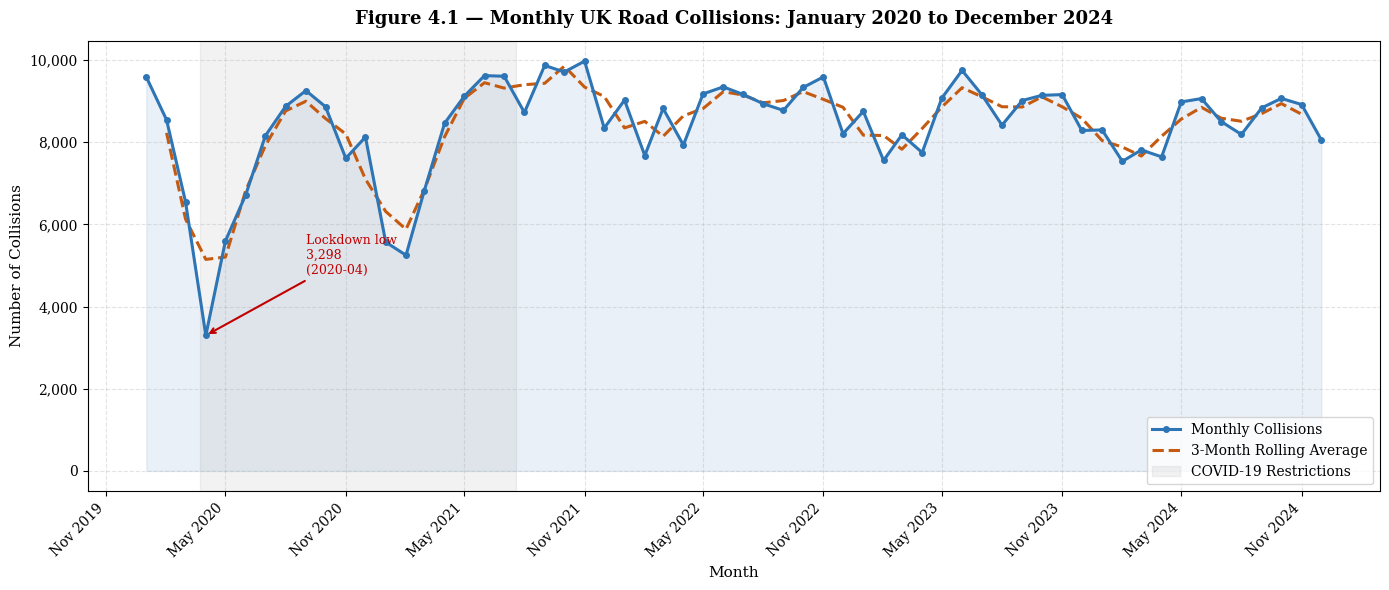


Section 8 complete — chart1_monthly_collisions.png saved.
   Lockdown low : 3,298 (2020-04)
   Y-axis max   : 9,975
   This is Figure 4.1 in your dissertation.


In [29]:
print("SECTION 8 — FIGURE 4.1: MONTHLY COLLISION TIME SERIES")
print("=" * 55)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_ts['yearmonth_dt'], monthly_ts['Total_Collision'],
        color='#2E75B6', linewidth=2.2, marker='o', markersize=4,
        label='Monthly Collisions', zorder=3)
ax.fill_between(monthly_ts['yearmonth_dt'], monthly_ts['Total_Collision'],
                alpha=0.10, color='#2E75B6')
ax.plot(monthly_ts['yearmonth_dt'], monthly_ts['rolling_3m'],
        color='#C55A11', linewidth=2.2, linestyle='--',
        label='3-Month Rolling Average', zorder=2)

# COVID-19 restriction shading
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2021-07-19'),
           alpha=0.10, color='#808080', label='COVID-19 Restrictions')

# Annotate lowest point
min_row = monthly_ts.loc[monthly_ts['Total_Collision'].idxmin()]
ax.annotate(
    f"Lockdown low\n{int(min_row['Total_Collision']):,}\n({min_row['yearmonth_str']})",
    xy=(min_row['yearmonth_dt'], min_row['Total_Collision']),
    xytext=(min_row['yearmonth_dt'] + pd.DateOffset(months=5),
            min_row['Total_Collision'] + 1500),
    fontsize=9, color='#C00000',
    arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.5)
)

ax.set_title('Figure 4.1 — Monthly UK Road Collisions: January 2020 to December 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Collisions', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('chart1_monthly_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSection 8 complete — chart1_monthly_collisions.png saved.")
print(f"   Lockdown low : {int(min_row['Total_Collision']):,} ({min_row['yearmonth_str']})")
print(f"   Y-axis max   : {monthly_ts['Total_Collision'].max():,}")
print(f"   This is Figure 4.1 in your dissertation.")


SECTION 9 Severity breakdown
-------------------------------------------------------


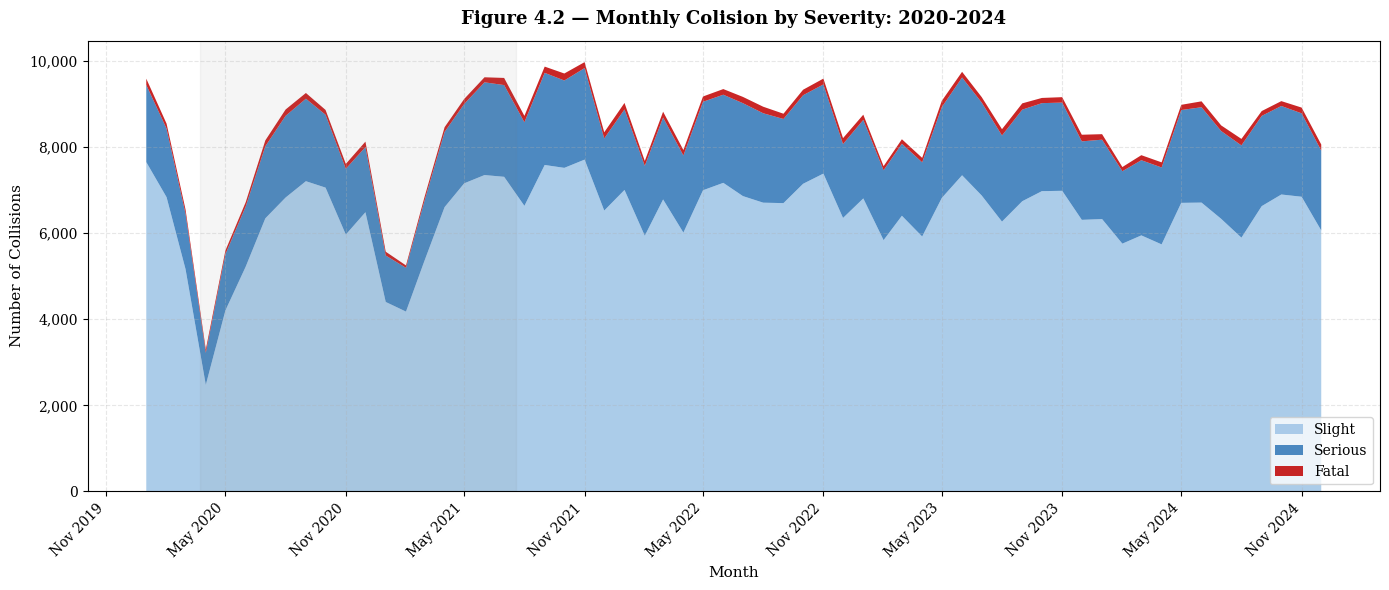

In [30]:
print("SECTION 9 Severity breakdown")
print("-" * 55)

sev_cols = [c for c in ['Slight', 'Serious', 'Fatal'] if c in monthly_ts.columns]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(monthly_ts['yearmonth_dt'],
             [monthly_ts[c] for c in sev_cols],
             labels=sev_cols,
             colors=['#9DC3E6', '#2E75B6', '#C00000'],
             alpha=0.85)
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2021-07-19'),
           alpha=0.08, color='gray')
ax.set_title('Figure 4.2 — Monthly Colision by Severity: 2020-2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Collisions', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_severity_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

SECTION 10 — FIGURE 4.3: SEASONAL PATTERN


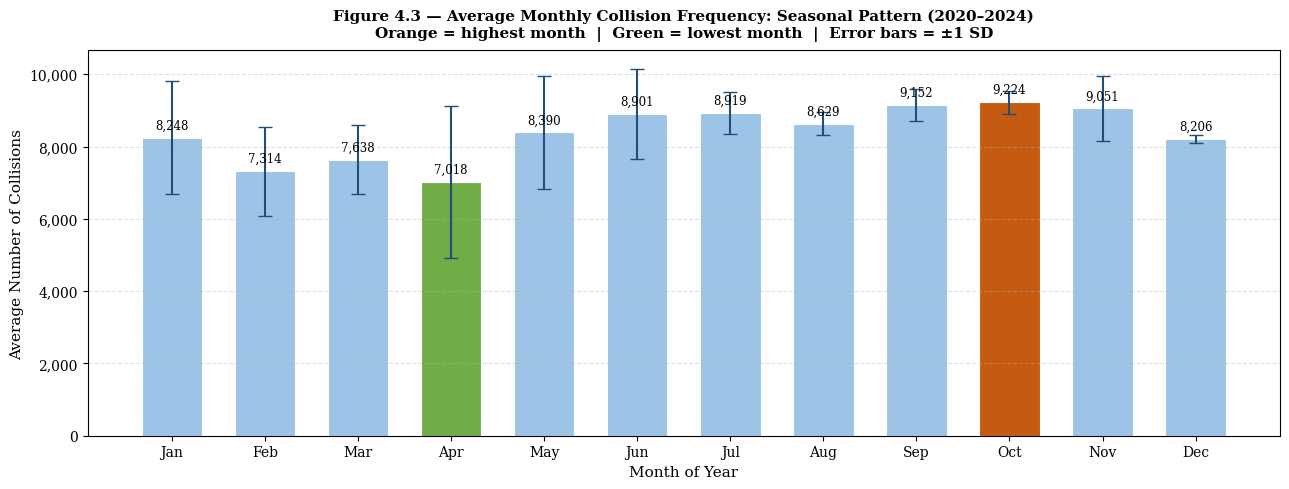


✅ Section 10 complete — chart3_seasonal_pattern.png saved.
   Peak month   : Oct  (9,224 avg collisions)
   Lowest month : Apr  (7,018 avg collisions)
   This is Figure 4.3 in your dissertation.


In [31]:
print("SECTION 10 — FIGURE 4.3: SEASONAL PATTERN")
print("=" * 55)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = monthly_ts.groupby('month_num').agg(
    Avg=('Total_Collision', 'mean'),
    Std=('Total_Collision', 'std')
).reset_index()

colors_bar = ['#9DC3E6'] * 12
max_idx = int(seasonal['Avg'].idxmax())
min_idx = int(seasonal['Avg'].idxmin())
colors_bar[max_idx] = '#C55A11'
colors_bar[min_idx] = '#70AD47'

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(1, 13), seasonal['Avg'],
              color=colors_bar, edgecolor='white', linewidth=0.8, width=0.65)
ax.errorbar(range(1, 13), seasonal['Avg'], yerr=seasonal['Std'],
            fmt='none', color='#1F4E79', capsize=5, linewidth=1.5)
for bar, val in zip(bars, seasonal['Avg']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + seasonal['Std'].max() * 0.08,
            f'{int(val):,}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Figure 4.3 — Average Monthly Collision Frequency: Seasonal Pattern (2020–2024)\n'
             'Orange = highest month  |  Green = lowest month  |  Error bars = ±1 SD',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Month of Year', fontsize=11)
ax.set_ylabel('Average Number of Collisions', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

peak_month   = month_labels[max_idx]
lowest_month = month_labels[min_idx]
print(f"\n✅ Section 10 complete — chart3_seasonal_pattern.png saved.")
print(f"   Peak month   : {peak_month}  ({seasonal['Avg'].max():,.0f} avg collisions)")
print(f"   Lowest month : {lowest_month}  ({seasonal['Avg'].min():,.0f} avg collisions)")
print(f"   This is Figure 4.3 in your dissertation.")



SECTION 11 — FIGURE 4.4: COLLISIONS vs FUEL PRICE


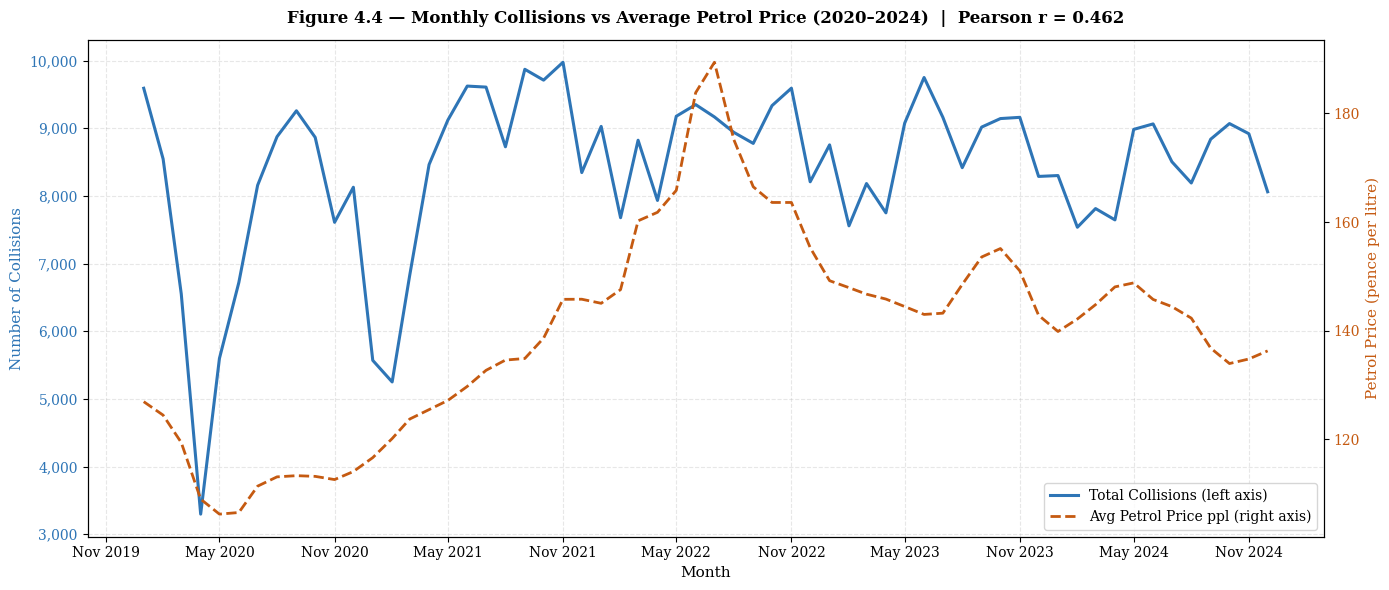


Section 11 complete — chart4_collisions_vs_fuel.png saved.
   This is Figure 4.4 in your dissertation.


In [32]:
print("SECTION 11 — FIGURE 4.4: COLLISIONS vs FUEL PRICE")
print("=" * 55)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(monthly_ts['yearmonth_dt'], monthly_ts['Total_Collision'],
         color='#2E75B6', linewidth=2.2,
         label='Total Collisions (left axis)', zorder=3)
ax2.plot(monthly_ts['yearmonth_dt'], monthly_ts['Petrol_ppl'],
         color='#C55A11', linewidth=2, linestyle='--',
         label='Avg Petrol Price ppl (right axis)', zorder=2)

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Number of Collisions', fontsize=11, color='#2E75B6')
ax2.set_ylabel('Petrol Price (pence per litre)', fontsize=11, color='#C55A11')
ax1.tick_params(axis='y', labelcolor='#2E75B6')
ax2.tick_params(axis='y', labelcolor='#C55A11')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower right', fontsize=10)
ax1.set_title(
    f'Figure 4.4 — Monthly Collisions vs Average Petrol Price (2020–2024)'
    f'  |  Pearson r = {r_petrol:.3f}',
    fontsize=12, fontweight='bold', pad=12)
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_collisions_vs_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSection 11 complete — chart4_collisions_vs_fuel.png saved.")
print(f"   This is Figure 4.4 in your dissertation.")

SECTION 12 — FIGURE 4.5: ENVIRONMENTAL CONDITIONS


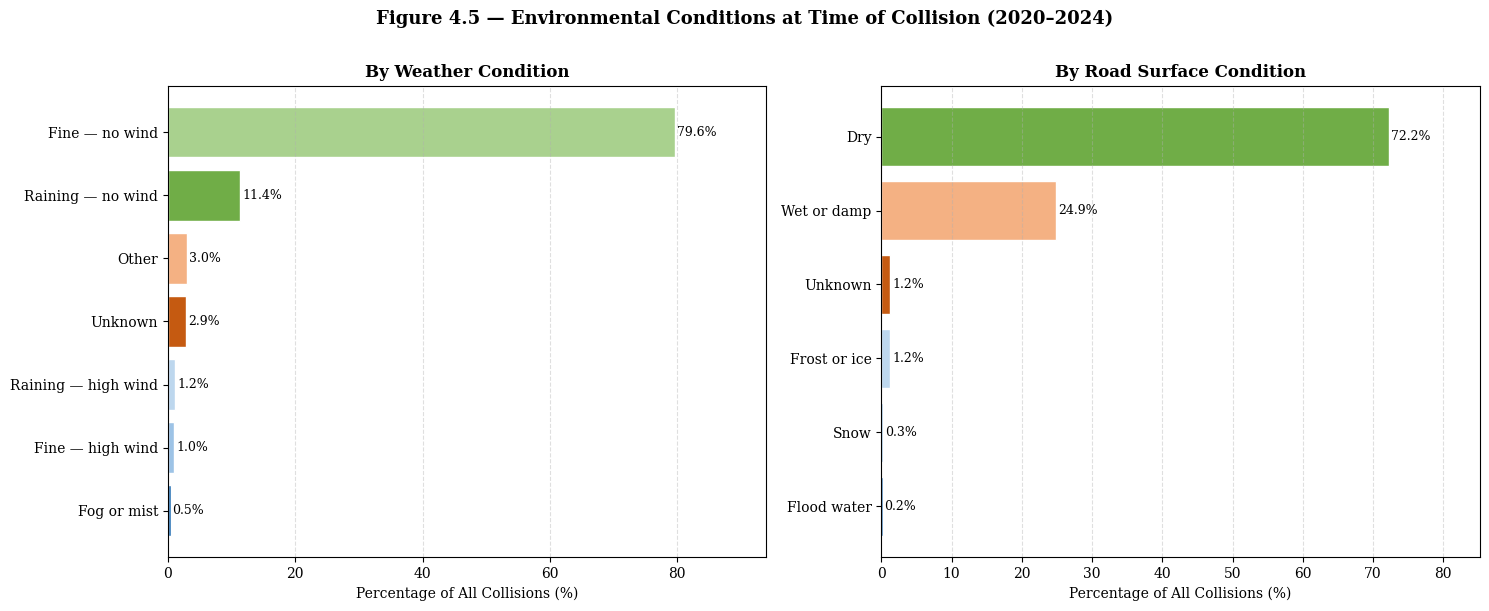


✅ Section 12 complete — chart5_environmental_conditions.png saved.
   This is Figure 4.5 in your dissertation.


In [33]:
print("SECTION 12 — FIGURE 4.5: ENVIRONMENTAL CONDITIONS")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Weather conditions
w_data   = (df['weather_label'].value_counts(normalize=True)*100).head(7)
colors_w = ['#2E75B6','#9DC3E6','#BDD7EE','#C55A11','#F4B183','#70AD47','#A9D18E']
axes[0].barh(w_data.index[::-1], w_data.values[::-1],
             color=colors_w[:len(w_data)], edgecolor='white')
for i, val in enumerate(w_data.values[::-1]):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('By Weather Condition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Percentage of All Collisions (%)', fontsize=10)
axes[0].set_xlim(0, w_data.values.max() * 1.18)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.4)

# Right: Road surface conditions
s_data   = (df['surface_label'].value_counts(normalize=True)*100).head(6)
colors_s = ['#2E75B6','#9DC3E6','#BDD7EE','#C55A11','#F4B183','#70AD47']
axes[1].barh(s_data.index[::-1], s_data.values[::-1],
             color=colors_s[:len(s_data)], edgecolor='white')
for i, val in enumerate(s_data.values[::-1]):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('By Road Surface Condition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage of All Collisions (%)', fontsize=10)
axes[1].set_xlim(0, s_data.values.max() * 1.18)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Figure 4.5 — Environmental Conditions at Time of Collision (2020–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart5_environmental_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Section 12 complete — chart5_environmental_conditions.png saved.")
print(f"   This is Figure 4.5 in your dissertation.")

SECTION 13 — FIGURE 4.6: SPEED LIMIT DISTRIBUTION


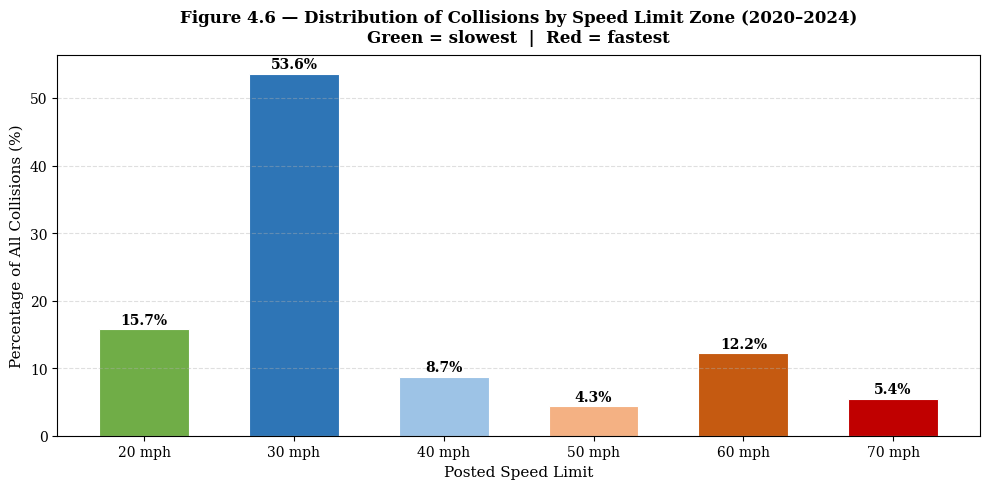


Section 13 complete — chart6_speed_limit.png saved.
   This is Figure 4.6 in your dissertation.


In [34]:
print("SECTION 13 — FIGURE 4.6: SPEED LIMIT DISTRIBUTION")
print("=" * 55)

valid = df[df['speed_limit'].isin([20, 30, 40, 50, 60, 70])]
sp_pct = (valid['speed_limit'].value_counts(normalize=True)*100).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#70AD47', '#2E75B6', '#9DC3E6', '#F4B183', '#C55A11', '#C00000']
bars = ax.bar([f'{s} mph' for s in sp_pct.index],
              sp_pct.values,
              color=bar_colors[:len(sp_pct)],
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, sp_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_title('Figure 4.6 — Distribution of Collisions by Speed Limit Zone (2020–2024)\n'
             'Green = slowest  |  Red = fastest',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Posted Speed Limit', fontsize=11)
ax.set_ylabel('Percentage of All Collisions (%)', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart6_speed_limit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSection 13 complete — chart6_speed_limit.png saved.")
print(f"   This is Figure 4.6 in your dissertation.")

In [35]:
print("SECTION 14 — DESCRIPTIVE STATISTICS TABLES")
print("=" * 65)

# Table 1: Monthly time series summary statistics
print("\n[TABLE 1] MONTHLY TIME SERIES — DESCRIPTIVE STATISTICS")
print("-" * 55)
desc = monthly_ts[['Total_Collision','Petrol_ppl','Diesel_ppl']].describe().round(2)
desc.index = ['Count','Mean','Std Dev','Min','25th Pctile',
              'Median','75th Pctile','Max']
desc.columns = ['Monthly Collisions','Petrol (ppl)','Diesel (ppl)']
print(desc.to_string())

# Table 2: Year-by-year summary
print("\n\n[TABLE 2] YEAR-BY-YEAR SUMMARY")
print("-" * 65)
yearly = monthly_ts.groupby('year_num').agg(
    Annual_Total    = ('Total_Collision', 'sum'),
    Monthly_Avg     = ('Total_Collision', 'mean'),
    Peak_Month      = ('Total_Collision', 'max'),
    Lowest_Month    = ('Total_Collision', 'min'),
    Avg_Petrol_ppl  = ('Petrol_ppl', 'mean')
).round(1)
yearly.index.name = 'Year'
print(yearly.to_string())

# Table 3: Severity by year
print("\n\n[TABLE 3] COLLISION SEVERITY BY YEAR")
print("-" * 65)
sev_year = df.groupby(['year', 'severity_label']).size().unstack(fill_value=0)
sev_year['Total'] = sev_year.sum(axis=1)
for col in ['Fatal', 'Serious', 'Slight']:
    if col in sev_year.columns:
        sev_year[f'{col}_%'] = (sev_year[col] / sev_year['Total'] * 100).round(1)
print(sev_year.to_string())

print(f"\nSection 14 complete — copy these tables into Chapter 4.")

SECTION 14 — DESCRIPTIVE STATISTICS TABLES

[TABLE 1] MONTHLY TIME SERIES — DESCRIPTIVE STATISTICS
-------------------------------------------------------
             Monthly Collisions  Petrol (ppl)  Diesel (ppl)
Count                     60.00         60.00         60.00
Mean                    8391.25        139.88        147.80
Std Dev                 1229.74         18.77         22.08
Min                     3298.00        106.24        112.67
25th Pctile             8029.00        126.58        130.60
Median                  8765.00        142.92        148.60
75th Pctile             9147.50        148.59        159.77
Max                     9975.00        189.42        197.84


[TABLE 2] YEAR-BY-YEAR SUMMARY
-----------------------------------------------------------------
      Annual_Total  Monthly_Avg  Peak_Month  Lowest_Month  Avg_Petrol_ppl
Year                                                                     
2020         91199       7599.9        9591          3298 

In [36]:
print("SECTION 15 — SAVE OUTPUT FILES")
print("=" * 55)

# Save monthly time series → Chapter 5
monthly_ts.to_csv('monthly_collision_timeseries.csv', index=False)

# Save clean individual records → Chapter 6
cols_to_keep = [c for c in [
    'date', 'year', 'month', 'yearmonth',
    'collision_severity', 'severity_label',
    'number_of_casualties', 'number_of_vehicles',
    'weather_conditions', 'weather_label',
    'road_surface_conditions', 'surface_label',
    'light_conditions', 'light_label',
    'speed_limit', 'urban_or_rural_area', 'urban_label',
    'day_of_week', 'day_name', 'is_weekend'
] if c in df.columns]

df[cols_to_keep].to_csv('collisions_clean_2020_2024.csv', index=False)

print(f"\n{'='*65}")
print(f"✅ ALL SECTIONS COMPLETE")
print(f"{'='*65}")

outputs = [
    ("monthly_collision_timeseries.csv",   "Chapter 5 — Time Series Forecasting"),
    ("collisions_clean_2020_2024.csv",      "Chapter 6 — Regression Analysis"),
    ("chart1_monthly_collisions.png",       "Chapter 4 — Figure 4.1"),
    ("chart2_severity_breakdown.png",       "Chapter 4 — Figure 4.2"),
    ("chart3_seasonal_pattern.png",         "Chapter 4 — Figure 4.3"),
    ("chart4_collisions_vs_fuel.png",       "Chapter 4 — Figure 4.4"),
    ("chart5_environmental_conditions.png", "Chapter 4 — Figure 4.5"),
    ("chart6_speed_limit.png",              "Chapter 4 — Figure 4.6"),
]

print(f"\n  {'File':<45}  Purpose")
print("  " + "-" * 75)
for fname, purpose in outputs:
    print(f"  {fname:<45}  {purpose}")

print(f"\n  All files saved to your working folder: /content")
print(f"\n  NEXT STEP: Run sections 1–15 in order in a fresh notebook.")
print(f"  Then proceed to Chapter 5 — Time Series Forecasting Models.")


SECTION 15 — SAVE OUTPUT FILES

✅ ALL SECTIONS COMPLETE

  File                                           Purpose
  ---------------------------------------------------------------------------
  monthly_collision_timeseries.csv               Chapter 5 — Time Series Forecasting
  collisions_clean_2020_2024.csv                 Chapter 6 — Regression Analysis
  chart1_monthly_collisions.png                  Chapter 4 — Figure 4.1
  chart2_severity_breakdown.png                  Chapter 4 — Figure 4.2
  chart3_seasonal_pattern.png                    Chapter 4 — Figure 4.3
  chart4_collisions_vs_fuel.png                  Chapter 4 — Figure 4.4
  chart5_environmental_conditions.png            Chapter 4 — Figure 4.5
  chart6_speed_limit.png                         Chapter 4 — Figure 4.6

  All files saved to your working folder: /content

  NEXT STEP: Run sections 1–15 in order in a fresh notebook.
  Then proceed to Chapter 5 — Time Series Forecasting Models.


**TIME SERIES FOR COLLISION**

In [37]:
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.family']      = 'serif'

In [38]:
# LOAD DATASET, SET DATETIME INDEX AND FREQUENCY
print("=" * 65)
print("STEPS 1–4: LOAD DATA AND SET DATETIME INDEX")
print("=" * 65)

ts = pd.read_csv('monthly_collision_timeseries.csv')
ts = ts.rename(columns={'Total_Collision': 'Total_Collisions'})  # ADD THIS LINE
ts['yearmonth_dt'] = pd.to_datetime(ts['yearmonth_str'])
ts = ts.sort_values('yearmonth_dt').reset_index(drop=True)
ts = ts.set_index('yearmonth_dt')
ts.index.freq = 'MS'

print(f"\nDataset loaded and datetime index set.")
print(f"   Rows      : {len(ts)}")
print(f"   Index     : {ts.index[0].strftime('%Y-%m')} to {ts.index[-1].strftime('%Y-%m')}")
print(f"   Frequency : {ts.index.freq}")
print(f"   Columns   : {list(ts.columns)}")

STEPS 1–4: LOAD DATA AND SET DATETIME INDEX

Dataset loaded and datetime index set.
   Rows      : 60
   Index     : 2020-01 to 2024-12
   Frequency : <MonthBegin>
   Columns   : ['yearmonth', 'Total_Collisions', 'Fatal', 'Serious', 'Slight', 'yearmonth_str', 'month_num', 'year_num', 'rolling_3m', 'Petrol_ppl', 'Diesel_ppl']


In [39]:
print("\n" + "=" * 65)
print("DATAFRAME OVERVIEW AND DATA TYPES")
print("=" * 65)
print(f"\n{ts[['Total_Collisions','Petrol_ppl','Diesel_ppl']].dtypes}")
print(f"\nFirst 5 rows:")
print(ts[['Total_Collisions','Petrol_ppl','Diesel_ppl']].head())



DATAFRAME OVERVIEW AND DATA TYPES

Total_Collisions      int64
Petrol_ppl          float64
Diesel_ppl          float64
dtype: object

First 5 rows:
              Total_Collisions  Petrol_ppl  Diesel_ppl
yearmonth_dt                                          
2020-01-01                9591      126.94      132.47
2020-02-01                8546      124.46      129.26
2020-03-01                6551      119.42      123.85
2020-04-01                3298      109.00      115.98
2020-05-01                5599      106.24      113.42


In [40]:
ts['Total_Collisions'] = ts['Total_Collisions'].astype(float)
ts['Petrol_ppl']       = ts['Petrol_ppl'].astype(float)
print(f"\nType confirmed as float64.")


Type confirmed as float64.


In [41]:
print("\n" + "=" * 65)
print("MISSING VALUES CHECK")
print("=" * 65)
missing = ts[['Total_Collisions','Petrol_ppl']].isnull().sum()
print(f"\n  Total_Collisions missing : {missing['Total_Collisions']}")
print(f"  Petrol_ppl missing       : {missing['Petrol_ppl']}")
print(f"\nNo missing values — no imputation required.")



MISSING VALUES CHECK

  Total_Collisions missing : 0
  Petrol_ppl missing       : 0

No missing values — no imputation required.


In [42]:
#Detecting outliers

Q1 = ts['Total_Collisions'].quantile(0.25)
Q3 = ts['Total_Collisions'].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find Outliers
outliers = ts[(ts['Total_Collisions'] < lower_bound) | (ts['Total_Collisions'] > upper_bound)]
print(outliers)

             yearmonth  Total_Collisions  Fatal  Serious  Slight  \
yearmonth_dt                                                       
2020-04-01     2020-04            3298.0     78      746    2474   
2020-05-01     2020-05            5599.0     87     1306    4206   
2021-01-01     2021-01            5570.0     88     1080    4402   
2021-02-01     2021-02            5251.0     56     1017    4178   

             yearmonth_str  month_num  year_num   rolling_3m  Petrol_ppl  \
yearmonth_dt                                                               
2020-04-01         2020-04          4      2020  5149.333333      109.00   
2020-05-01         2020-05          5      2020  5206.000000      106.24   
2021-01-01         2021-01          1      2021  6316.333333      116.64   
2021-02-01         2021-02          2      2021  5881.666667      120.15   

              Diesel_ppl  
yearmonth_dt              
2020-04-01        115.98  
2020-05-01        113.42  
2021-01-01        121.20  

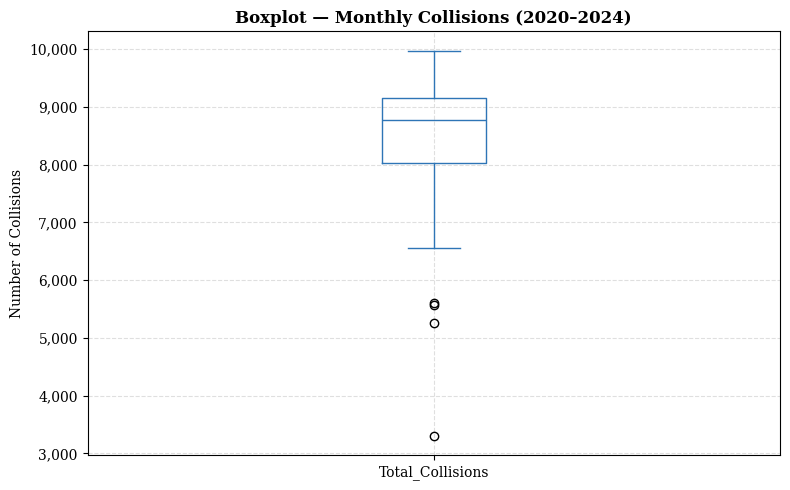

Saved: ch5_boxplot_outliers.png


In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
ts['Total_Collisions'].plot(kind='box', ax=ax, color='#2E75B6')
ax.set_title('Boxplot — Monthly Collisions (2020–2024)', fontweight='bold')
ax.set_ylabel('Number of Collisions')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch5_boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ch5_boxplot_outliers.png")


Step 10: Generating time series visualisation...


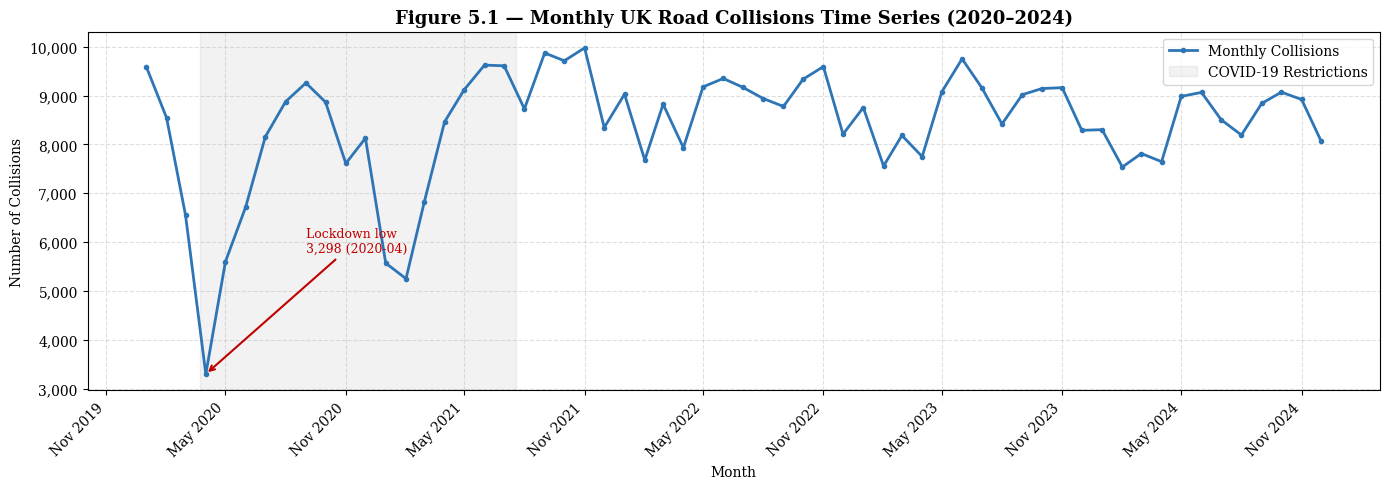

   Saved: ch5_fig1_timeseries.png


In [44]:
print("\nStep 10: Generating time series visualisation...")
y_full = ts['Total_Collisions']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_full, color='#2E75B6', linewidth=2, marker='o', markersize=3, label='Monthly Collisions')
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2021-07-19'),
           alpha=0.10, color='gray', label='COVID-19 Restrictions')
min_idx = y_full.idxmin()
ax.annotate(f'Lockdown low\n{int(y_full.min()):,} ({min_idx.strftime("%Y-%m")})',
            xy=(min_idx, y_full.min()),
            xytext=(min_idx + pd.DateOffset(months=5),
            y_full.min() + 2500),
            fontsize=9, color='#C00000',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.5))
ax.set_title('Figure 5.1 — Monthly UK Road Collisions Time Series (2020–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Number of Collisions')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch5_fig1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig1_timeseries.png")


SEASONAL DECOMPOSITION AND SMOOTHING


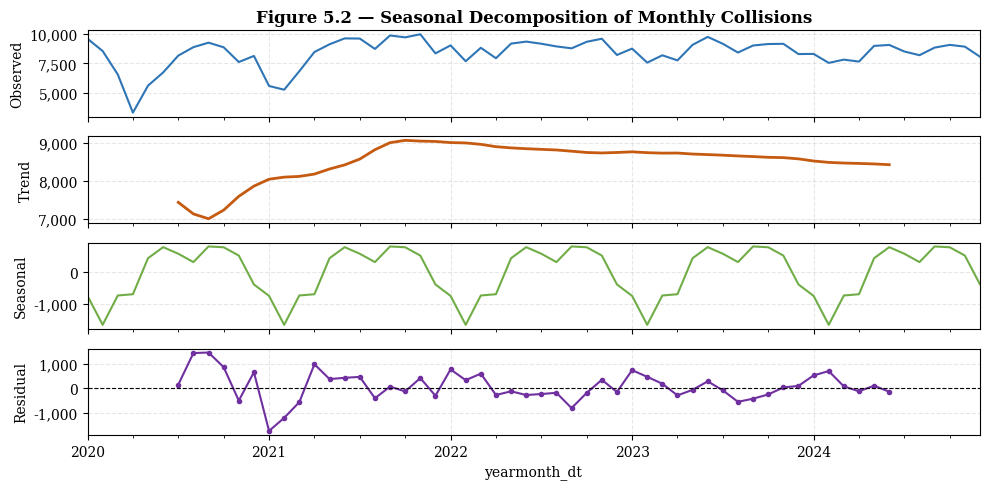

   Saved: ch5_fig2_decomposition.png

   Seasonal strength (std ratio) : 0.633
   Trend strength    (std ratio) : 0.411

Decomposition complete. Clear annual seasonal pattern confirmed.


In [45]:
print("\n" + "=" * 65)
print("SEASONAL DECOMPOSITION AND SMOOTHING")
print("=" * 65)

decomp = seasonal_decompose(y_full, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(10, 5), sharex=True)
decomp.observed.plot(ax=axes[0], color='#2E75B6', linewidth=1.5)
axes[0].set_ylabel('Observed'); axes[0].set_title('Figure 5.2 — Seasonal Decomposition of Monthly Collisions', fontweight='bold', fontsize=12)
decomp.trend.plot(ax=axes[1], color='#C55A11', linewidth=2)
axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='#70AD47', linewidth=1.5)
axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3], color='#7030A0', linewidth=1.5, marker='o', markersize=3)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('ch5_fig2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig2_decomposition.png")

seasonal_strength = decomp.seasonal.std() / y_full.std()
trend_strength    = decomp.trend.dropna().std() / y_full.std()
print(f"\n   Seasonal strength (std ratio) : {seasonal_strength:.3f}")
print(f"   Trend strength    (std ratio) : {trend_strength:.3f}")
print(f"\nDecomposition complete. Clear annual seasonal pattern confirmed.")


In [46]:
print("\n" + "=" * 65)
print("STATIONARITY TEST (ADF)")
print("=" * 65)

adf_result = adfuller(y_full, autolag='AIC')
print(f"\n  ADF Statistic  : {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.4f}")
print(f"  Critical Values:")
for k, v in adf_result[4].items():
    print(f"    {k} : {v:.4f}")

if adf_result[1] < 0.05:
    print(f"\nSeries is STATIONARY (p < 0.05). No differencing required.")
    stationary = True
else:
    print(f"\nSeries is NON-STATIONARY (p ≥ 0.05). First differencing applied.")
    stationary = False


STATIONARITY TEST (ADF)

  ADF Statistic  : -4.7885
  p-value        : 0.0001
  Critical Values:
    1% : -3.5507
    5% : -2.9138
    10% : -2.5946

Series is STATIONARY (p < 0.05). No differencing required.



Generating ACF and PACF plots...


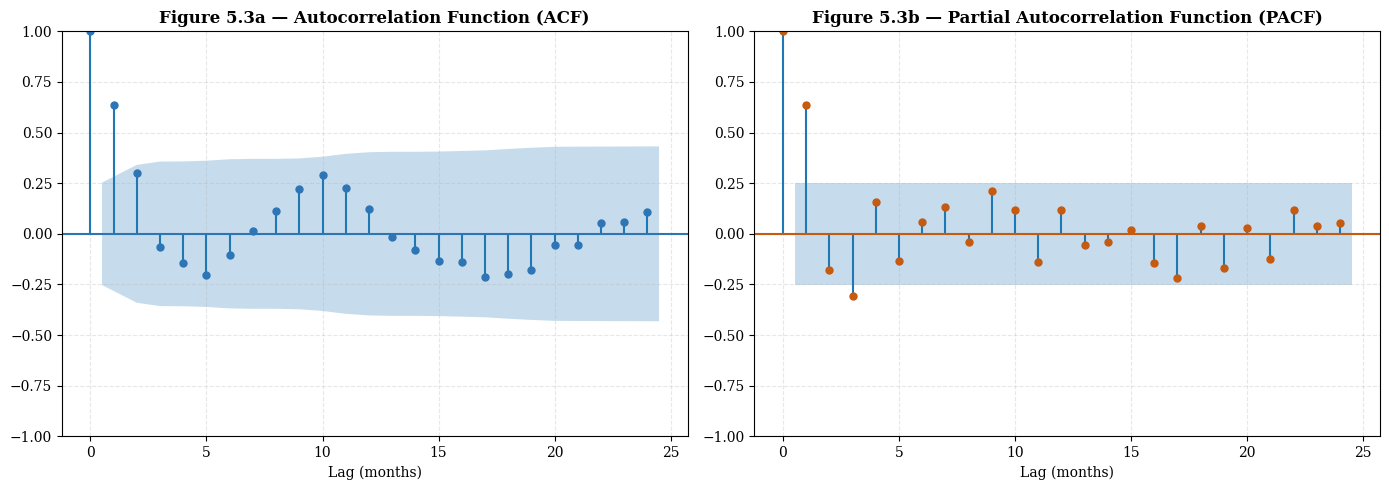

   Saved: ch5_fig3_acf_pacf.png


In [47]:
print("\nGenerating ACF and PACF plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y_full, lags=24, ax=axes[0], color='#2E75B6')
axes[0].set_title('Figure 5.3a — Autocorrelation Function (ACF)', fontweight='bold')
axes[0].set_xlabel('Lag (months)')
plot_pacf(y_full, lags=24, ax=axes[1], color='#C55A11', method='ywm')
axes[1].set_title('Figure 5.3b — Partial Autocorrelation Function (PACF)', fontweight='bold')
axes[1].set_xlabel('Lag (months)')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('ch5_fig3_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig3_acf_pacf.png")

In [48]:
print("\n" + "=" * 65)
print("LJUNG-BOX AUTOCORRELATION TEST")
print("=" * 65)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(y_full, lags=[12, 24], return_df=True)
print(f"\n{lb_result}")
print(f"\n  Significant autocorrelation present (p < 0.05) confirms")
print(f"  time series structure — ARIMA/SARIMA modelling justified.")


LJUNG-BOX AUTOCORRELATION TEST

      lb_stat     lb_pvalue
12  52.199789  5.714229e-07
24  68.664989  3.476501e-06

  Significant autocorrelation present (p < 0.05) confirms
  time series structure — ARIMA/SARIMA modelling justified.


In [49]:
print("\n" + "=" * 65)
print("TRAIN / TEST SPLIT")
print("=" * 65)

TRAIN_N = 48
y_train = y_full.iloc[:TRAIN_N]
y_test  = y_full.iloc[TRAIN_N:]

print(f"\n  Training set : {len(y_train)} months  ({y_train.index[0].strftime('%Y-%m')} — {y_train.index[-1].strftime('%Y-%m')})")
print(f"  Test set     : {len(y_test)} months   ({y_test.index[0].strftime('%Y-%m')} — {y_test.index[-1].strftime('%Y-%m')})")
print(f"\n  Training mean : {y_train.mean():,.0f}")
print(f"  Test mean     : {y_test.mean():,.0f}")


TRAIN / TEST SPLIT

  Training set : 48 months  (2020-01 — 2023-12)
  Test set     : 12 months   (2024-01 — 2024-12)

  Training mean : 8,386
  Test mean     : 8,411


In [50]:
print("\n" + "=" * 65)
print("BUILD FORECASTING MODELS")
print("=" * 65)

# ── MODEL 1: SIMPLE MOVING AVERAGE
print("\n[MODEL 1] Simple Moving Average (3-month window)")
sma_pred = y_train.rolling(window=3).mean().iloc[-1]
sma_forecast = pd.Series([sma_pred] * len(y_test), index=y_test.index)
print(f"   SMA value used for forecast : {sma_pred:,.0f}")

# ── MODEL 2: ARIMA
print("\n[MODEL 2] ARIMA — auto_arima parameter selection")
arima_model = auto_arima(y_train, seasonal=False, stepwise=True,
                          information_criterion='aic', trace=False,
                          error_action='ignore', suppress_warnings=True)
arima_order = arima_model.order
arima_forecast_obj = arima_model.predict(n_periods=len(y_test))
arima_forecast = pd.Series(arima_forecast_obj, index=y_test.index)
print(f"   Best ARIMA order : {arima_order}")
print(f"   AIC              : {arima_model.aic():.2f}")

# ── MODEL 3: SARIMA
print("\n[MODEL 3] SARIMA — auto_arima with seasonal=True (s=12)")
sarima_model = auto_arima(y_train, seasonal=True, m=12, stepwise=True,
                           information_criterion='aic', trace=False,
                           error_action='ignore', suppress_warnings=True,
                           max_p=3, max_q=3, max_P=2, max_Q=2)
sarima_order         = sarima_model.order
sarima_seasonal_order = sarima_model.seasonal_order
sarima_forecast_obj  = sarima_model.predict(n_periods=len(y_test))
sarima_forecast = pd.Series(sarima_forecast_obj, index=y_test.index)
print(f"   Best SARIMA order : {sarima_order}{sarima_seasonal_order}")
print(f"   AIC               : {sarima_model.aic():.2f}")

# ── MODEL 4: EXPONENTIAL SMOOTHING (HOLT-WINTERS)
print("\n[MODEL 4] Exponential Smoothing — Holt-Winters Triple")
hw_model = ExponentialSmoothing(y_train, trend='add', seasonal='add',
                                 seasonal_periods=12).fit(optimized=True)
hw_forecast = hw_model.forecast(len(y_test))
hw_forecast.index = y_test.index
print(f"   Alpha (level)    : {hw_model.params['smoothing_level']:.4f}")
print(f"   Beta  (trend)    : {hw_model.params['smoothing_trend']:.4f}")
print(f"   Gamma (seasonal) : {hw_model.params['smoothing_seasonal']:.4f}")
print(f"   SSE              : {hw_model.sse:,.2f}")



BUILD FORECASTING MODELS

[MODEL 1] Simple Moving Average (3-month window)
   SMA value used for forecast : 8,864

[MODEL 2] ARIMA — auto_arima parameter selection
   Best ARIMA order : (1, 0, 0)
   AIC              : 807.19

[MODEL 3] SARIMA — auto_arima with seasonal=True (s=12)
   Best SARIMA order : (1, 0, 0)(0, 0, 0, 12)
   AIC               : 807.19

[MODEL 4] Exponential Smoothing — Holt-Winters Triple
   Alpha (level)    : 1.0000
   Beta  (trend)    : 0.0307
   Gamma (seasonal) : 0.0000
   SSE              : 52,881,483.06


In [51]:
print("\n" + "=" * 65)
print("STEPS 21–23: MODEL EVALUATION — ACCURACY METRICS")
print("=" * 65)

def calc_metrics(actual, predicted, name):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae  = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results = [
    calc_metrics(y_test, sma_forecast,   'Simple Moving Average'),
    calc_metrics(y_test, arima_forecast,  f'ARIMA{arima_order}'),
    calc_metrics(y_test, sarima_forecast, f'SARIMA{sarima_order}{sarima_seasonal_order}'),
    calc_metrics(y_test, hw_forecast,     'Holt-Winters ETS'),
]

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(2)

print(f"\n{'Model':<40} {'MAE':>10} {'RMSE':>10} {'MAPE (%)':>10}")
print("-" * 72)
for idx, row in results_df.iterrows():
    print(f"  {idx:<38} {row['MAE']:>10,.2f} {row['RMSE']:>10,.2f} {row['MAPE (%)']:>9.2f}%")

best_model = results_df['MAE'].idxmin()
print(f"\n Best model by MAE  : {best_model}")
best_rmse  = results_df['RMSE'].idxmin()
print(f" Best model by RMSE : {best_rmse}")
best_mape  = results_df['MAPE (%)'].idxmin()
print(f" Best model by MAPE : {best_mape}")


STEPS 21–23: MODEL EVALUATION — ACCURACY METRICS

Model                                           MAE       RMSE   MAPE (%)
------------------------------------------------------------------------
  Simple Moving Average                      549.92     706.67      6.91%
  ARIMA(1, 0, 0)                             471.40     530.02      5.66%
  SARIMA(1, 0, 0)(0, 0, 0, 12)               471.40     530.02      5.66%
  Holt-Winters ETS                           280.99     339.86      3.41%

 Best model by MAE  : Holt-Winters ETS
 Best model by RMSE : Holt-Winters ETS
 Best model by MAPE : Holt-Winters ETS



✅ Step 22: Generating actuals vs predicted chart...


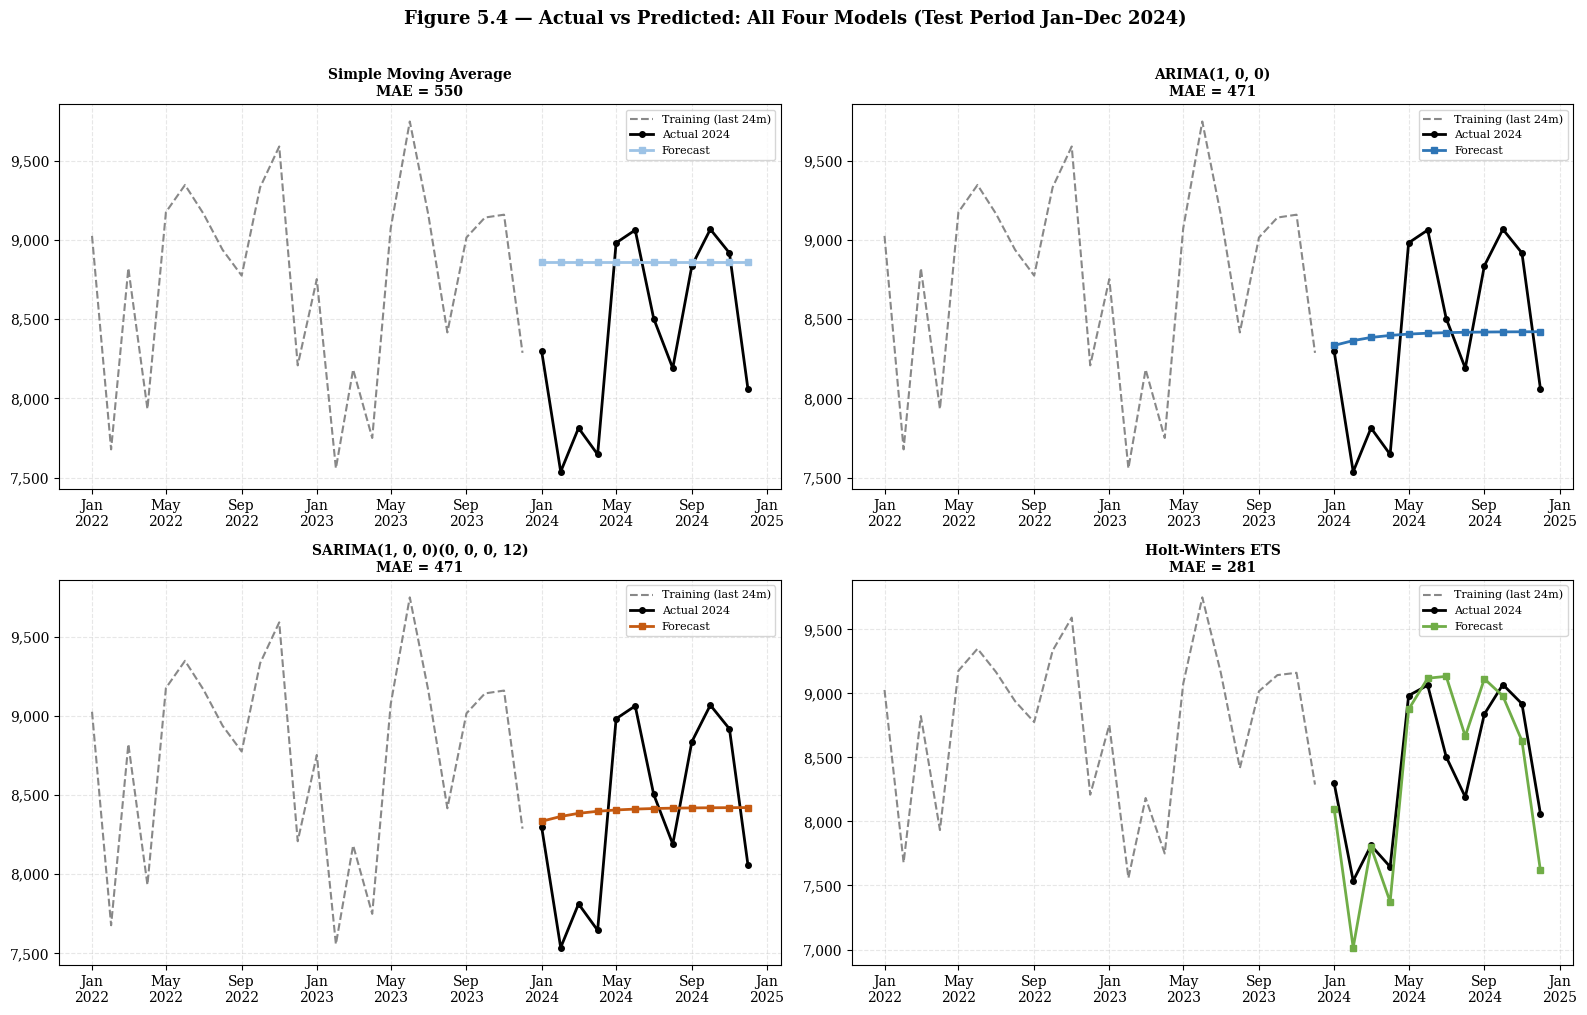

   Saved: ch5_fig4_actual_vs_predicted.png


In [52]:
print("\n✅ Step 22: Generating actuals vs predicted chart...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
models_plot = [
    ('Simple Moving Average', sma_forecast,   '#9DC3E6'),
    (f'ARIMA{arima_order}',   arima_forecast,  '#2E75B6'),
    (f'SARIMA{sarima_order}{sarima_seasonal_order}', sarima_forecast, '#C55A11'),
    ('Holt-Winters ETS',      hw_forecast,     '#70AD47'),
]

for ax, (name, forecast, color) in zip(axes.flatten(), models_plot):
    ax.plot(y_train[-24:], color='#888888', linewidth=1.5, label='Training (last 24m)', linestyle='--')
    ax.plot(y_test, color='black', linewidth=2, marker='o', markersize=4, label='Actual 2024')
    ax.plot(forecast, color=color, linewidth=2, marker='s', markersize=4, label=f'Forecast')
    mae_val = calc_metrics(y_test, forecast, name)['MAE']
    ax.set_title(f'{name}\nMAE = {mae_val:,.0f}', fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Figure 5.4 — Actual vs Predicted: All Four Models (Test Period Jan–Dec 2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ch5_fig4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig4_actual_vs_predicted.png")


Generating model comparison bar chart...


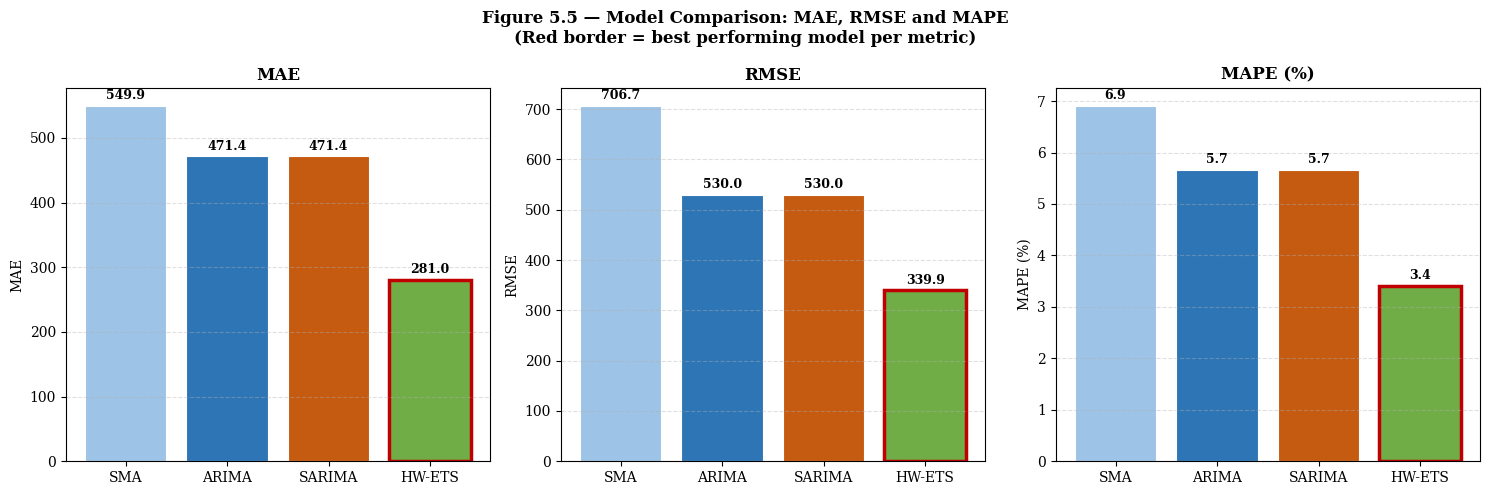

   Saved: ch5_fig5_model_comparison.png


In [53]:
print("\nGenerating model comparison bar chart...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'MAPE (%)']
colors  = ['#9DC3E6', '#2E75B6', '#C55A11', '#70AD47']
labels  = ['SMA', f'ARIMA', 'SARIMA', 'HW-ETS']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max()*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    # Highlight best
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor('#C00000')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Figure 5.5 — Model Comparison: MAE, RMSE and MAPE\n(Red border = best performing model per metric)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ch5_fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig5_model_comparison.png")



RESIDUAL DIAGNOSTICS

  Durbin-Watson statistics (test residuals):
  Model                   DW Stat  Interpretation
  ------------------------------------------------------------
  SMA                      0.6881  Some autocorrelation
  ARIMA                    1.2298  Some autocorrelation
  SARIMA                   1.2298  Some autocorrelation
  HW-ETS                   0.7737  Some autocorrelation

  Shapiro-Wilk normality test on HW-ETS residuals:
  Statistic : 0.9477
  p-value   : 0.6037
  Residuals are normally distributed (p > 0.05)


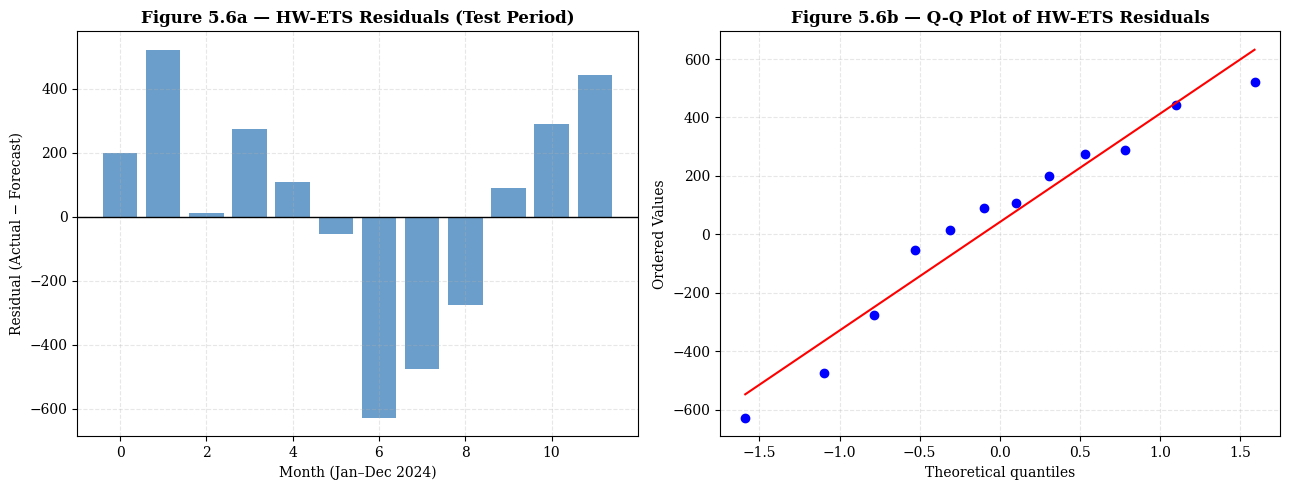

   Saved: ch5_fig6_residuals.png


In [54]:
print("\n" + "=" * 65)
print("RESIDUAL DIAGNOSTICS")
print("=" * 65)

# Use best model residuals for diagnostics
forecasts_dict = {
    'SMA'     : sma_forecast,
    'ARIMA'   : arima_forecast,
    'SARIMA'  : sarima_forecast,
    'HW-ETS'  : hw_forecast,
}

print(f"\n  Durbin-Watson statistics (test residuals):")
print(f"  {'Model':<20} {'DW Stat':>10}  {'Interpretation'}")
print(f"  {'-'*60}")
for name, fc in forecasts_dict.items():
    resid = y_test.values - np.array(fc)
    dw = durbin_watson(resid)
    interp = "No autocorrelation" if 1.5 < dw < 2.5 else "Some autocorrelation"
    print(f"  {name:<20} {dw:>10.4f}  {interp}")

# RESIDUAL NORMALITY TEST AND PLOT — FIXED
best_key = 'HW-ETS'  # hardcoded to best model
best_resid = y_test.values - np.array(forecasts_dict[best_key])

shapiro_stat, shapiro_p = stats.shapiro(best_resid)
print(f"\n  Shapiro-Wilk normality test on {best_key} residuals:")
print(f"  Statistic : {shapiro_stat:.4f}")
print(f"  p-value   : {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print(f"  Residuals are normally distributed (p > 0.05)")
else:
    print(f"  Residuals deviate from normality (p < 0.05)")

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(len(best_resid)), best_resid, color='#2E75B6', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title(f'Figure 5.6a — {best_key} Residuals (Test Period)', fontweight='bold')
axes[0].set_xlabel('Month (Jan–Dec 2024)')
axes[0].set_ylabel('Residual (Actual − Forecast)')
axes[0].grid(True, linestyle='--', alpha=0.3)
stats.probplot(best_resid, dist="norm", plot=axes[1])
axes[1].set_title(f'Figure 5.6b — Q-Q Plot of {best_key} Residuals', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('ch5_fig6_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch5_fig6_residuals.png")



STEPS 26–27: FUTURE FORECAST (Jan–Dec 2025) AND VISUALISATION

  2025 Monthly Forecast (SARIMA — full series fit):
  Month          Forecast    Lower 95% CI    Upper 95% CI
  ------------------------------------------------------
  2025-01           7,969           6,322           9,616
  2025-02           7,886           5,860           9,912
  2025-03           8,119           5,869          10,369
  2025-04           8,311           6,050          10,571
  2025-05           8,496           6,229          10,763
  2025-06           8,563           6,252          10,874
  2025-07           8,559           6,211          10,906
  2025-08           8,497           6,133          10,860
  2025-09           8,429           6,064          10,793
  2025-10           8,376           6,011          10,741
  2025-11           8,355           5,985          10,724
  2025-12           8,359           5,986          10,732

  2025 Annual Forecast Total : 99,917 collisions
  2024 Actual Annual To

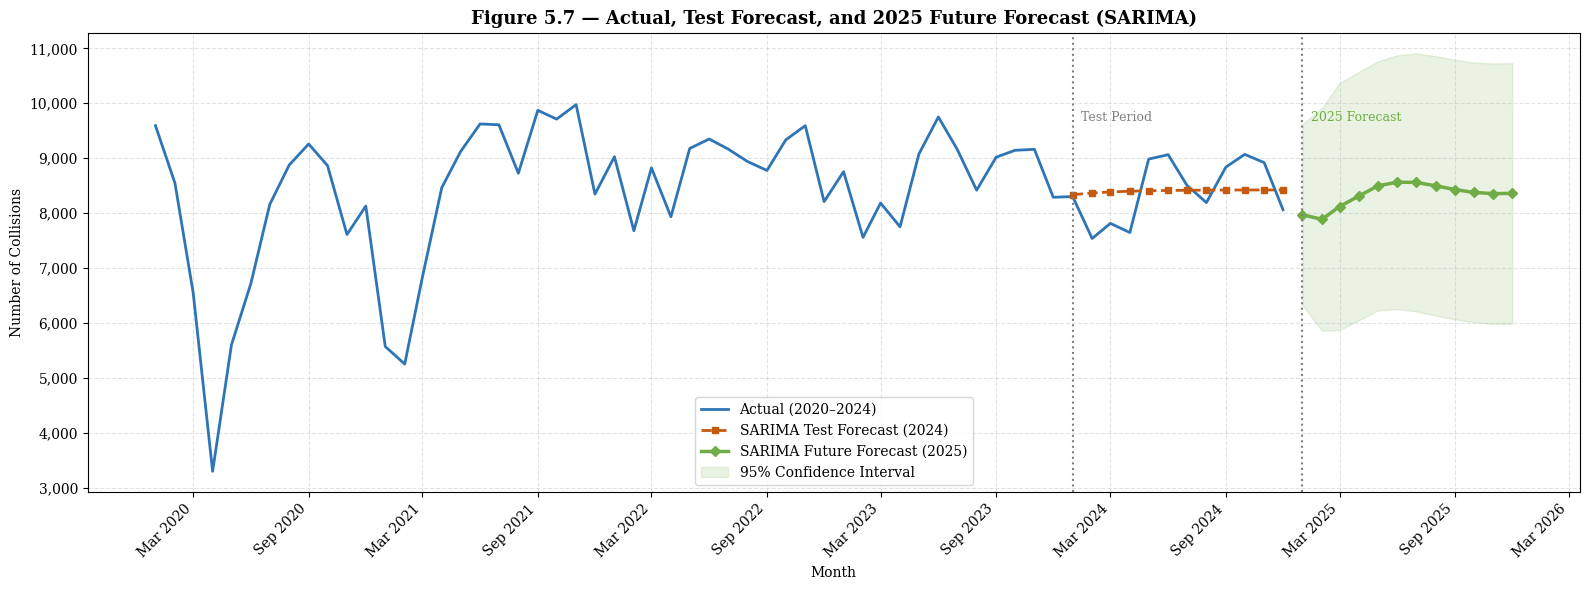


   Saved: ch5_fig7_future_forecast.png

✅ ALL 27 STEPS COMPLETE

Files saved:
  ch5_fig1_timeseries.png
  ch5_fig2_decomposition.png
  ch5_fig3_acf_pacf.png
  ch5_fig4_actual_vs_predicted.png
  ch5_fig5_model_comparison.png
  ch5_fig6_residuals.png
  ch5_fig7_future_forecast.png


In [55]:
print("\n" + "=" * 65)
print("STEPS 26–27: FUTURE FORECAST (Jan–Dec 2025) AND VISUALISATION")
print("=" * 65)

FUTURE_N = 12
future_idx = pd.date_range(start='2025-01-01', periods=FUTURE_N, freq='MS')

# Re-fit best model on full series for future forecast
sarima_full = auto_arima(y_full, seasonal=True, m=12, stepwise=True,
                          information_criterion='aic', trace=False,
                          error_action='ignore', suppress_warnings=True,
                          max_p=3, max_q=3, max_P=2, max_Q=2)
future_forecast = pd.Series(sarima_full.predict(n_periods=FUTURE_N), index=future_idx)
conf_int = sarima_full.predict(n_periods=FUTURE_N, return_conf_int=True)
lower_ci = pd.Series(conf_int[1][:,0], index=future_idx)
upper_ci = pd.Series(conf_int[1][:,1], index=future_idx)

print(f"\n  2025 Monthly Forecast (SARIMA — full series fit):")
print(f"  {'Month':<12} {'Forecast':>10}  {'Lower 95% CI':>14}  {'Upper 95% CI':>14}")
print(f"  {'-'*54}")
for i in range(FUTURE_N):
    print(f"  {future_idx[i].strftime('%Y-%m'):<12} {future_forecast.iloc[i]:>10,.0f}  {lower_ci.iloc[i]:>14,.0f}  {upper_ci.iloc[i]:>14,.0f}")

print(f"\n  2025 Annual Forecast Total : {future_forecast.sum():,.0f} collisions")
print(f"  2024 Actual Annual Total   : {int(y_full.iloc[48:].sum()):,.0f} collisions")

# Final combined visualisation
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_full, color='#2E75B6', linewidth=2, label='Actual (2020–2024)')
ax.plot(sarima_forecast, color='#C55A11', linewidth=2,
        linestyle='--', marker='s', markersize=4, label='SARIMA Test Forecast (2024)')
ax.plot(future_forecast, color='#70AD47', linewidth=2.5,
        linestyle='-', marker='D', markersize=5, label='SARIMA Future Forecast (2025)')
ax.fill_between(future_idx, lower_ci, upper_ci, alpha=0.15, color='#70AD47', label='95% Confidence Interval')
ax.axvline(x=pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.5)
ax.axvline(x=pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2024-01-15'), y_full.max()*0.97, 'Test Period', fontsize=9, color='gray')
ax.text(pd.Timestamp('2025-01-15'), y_full.max()*0.97, '2025 Forecast', fontsize=9, color='#70AD47')
ax.set_title('Figure 5.7 — Actual, Test Forecast, and 2025 Future Forecast (SARIMA)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Number of Collisions')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('ch5_fig7_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   Saved: ch5_fig7_future_forecast.png")

print("\n" + "=" * 65)
print("✅ ALL 27 STEPS COMPLETE")
print("=" * 65)
print("\nFiles saved:")
files = ['ch5_fig1_timeseries.png','ch5_fig2_decomposition.png',
         'ch5_fig3_acf_pacf.png','ch5_fig4_actual_vs_predicted.png',
         'ch5_fig5_model_comparison.png','ch5_fig6_residuals.png',
         'ch5_fig7_future_forecast.png']
for f in files:
    print(f"  {f}")

In [56]:
# Force a SARIMA with seasonal parameters and compare
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_forced = SARIMAX(y_train, order=(1,0,0),
                         seasonal_order=(1,0,1,12)).fit(disp=False)
forced_forecast = sarima_forced.forecast(steps=12)
forced_forecast.index = y_test.index
forced_mae = np.mean(np.abs(y_test.values - forced_forecast.values))
print(f"Forced SARIMA(1,0,0)(1,0,1,12) MAE: {forced_mae:.2f}")
print(f"Auto SARIMA MAE: 471.40")
print(f"HW-ETS MAE: 280.99")

Forced SARIMA(1,0,0)(1,0,1,12) MAE: 415.51
Auto SARIMA MAE: 471.40
HW-ETS MAE: 280.99


In [57]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3, test_size=12)
cv_results = {'SMA': [], 'ARIMA': [], 'HW-ETS': []}

for train_idx, test_idx in tscv.split(y_full):
    y_tr = y_full.iloc[train_idx]
    y_te = y_full.iloc[test_idx]

    # SMA
    sma_cv = np.full(len(y_te), y_tr.rolling(3).mean().iloc[-1])
    cv_results['SMA'].append(np.mean(np.abs(y_te.values - sma_cv)))

    # ARIMA
    ar_cv = auto_arima(y_tr, seasonal=False, stepwise=True,
                        suppress_warnings=True, error_action='ignore')
    ar_fc = ar_cv.predict(n_periods=len(y_te))
    cv_results['ARIMA'].append(np.mean(np.abs(y_te.values - ar_fc)))

    # HW-ETS
    if len(y_tr) >= 24:
        hw_cv = ExponentialSmoothing(y_tr, trend='add', seasonal='add',
                                      seasonal_periods=12).fit(optimized=True)
        hw_fc = hw_cv.forecast(len(y_te))
        cv_results['HW-ETS'].append(np.mean(np.abs(y_te.values - hw_fc.values)))

print("Cross-Validation MAE (3-fold rolling origin):")
print(f"{'Model':<20} {'Mean MAE':>12}  {'Std Dev':>10}")
print("-" * 46)
for model, scores in cv_results.items():
    if scores:
        print(f"  {model:<18} {np.mean(scores):>12,.2f}  {np.std(scores):>10,.2f}")

Cross-Validation MAE (3-fold rolling origin):
Model                    Mean MAE     Std Dev
----------------------------------------------
  SMA                      545.56        7.88
  ARIMA                    700.67      231.46
  HW-ETS                 1,248.56      809.85


In [58]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_full = ExponentialSmoothing(y_full, trend='add', seasonal='add',
                                seasonal_periods=12).fit(optimized=True)

# Simulate prediction intervals via bootstrap
n_simulations = 1000
future_n = 12
future_idx = pd.date_range(start='2025-01-01', periods=future_n, freq='MS')
simulations = []

resid_std = np.std(hw_full.resid)
for _ in range(n_simulations):
    noise = np.random.normal(0, resid_std, future_n)
    sim = hw_full.forecast(future_n) + noise
    simulations.append(sim.values)

sims_array = np.array(simulations)
lower_hw = np.percentile(sims_array, 2.5, axis=0)
upper_hw = np.percentile(sims_array, 97.5, axis=0)
point_hw = hw_full.forecast(future_n)

print("HW-ETS 2025 Forecast with 95% Prediction Intervals:")
print(f"{'Month':<12} {'Forecast':>10} {'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 48)
for i in range(future_n):
    print(f"{future_idx[i].strftime('%Y-%m'):<12} {point_hw.iloc[i]:>10,.0f} "
          f"{lower_hw[i]:>12,.0f} {upper_hw[i]:>12,.0f}")

HW-ETS 2025 Forecast with 95% Prediction Intervals:
Month          Forecast    Lower 95%    Upper 95%
------------------------------------------------
2025-01           7,717        6,082        9,252
2025-02           6,779        5,260        8,386
2025-03           7,121        5,642        8,748
2025-04           6,520        4,893        8,054
2025-05           7,892        6,268        9,467
2025-06           8,402        6,968       10,088
2025-07           8,426        6,787       10,001
2025-08           8,148        6,632        9,622
2025-09           8,689        7,155       10,322
2025-10           8,771        7,256       10,363
2025-11           8,604        6,958       10,221
2025-12           7,753        6,256        9,294


In [59]:
from scipy import stats

def diebold_mariano(actual, pred1, pred2):
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=len(d)-1))
    return dm_stat, p_value

actual = y_test.values
models_fc = {
    'SMA vs HW-ETS'   : (sma_forecast.values,   hw_forecast.values),
    'ARIMA vs HW-ETS' : (arima_forecast.values,  hw_forecast.values),
    'SARIMA vs HW-ETS': (sarima_forecast.values, hw_forecast.values),
}

print("Diebold-Mariano Test (H0: equal forecast accuracy)")
print(f"{'Comparison':<25} {'DM Stat':>10} {'p-value':>10} {'Significant?':>14}")
print("-" * 62)
for name, (fc1, fc2) in models_fc.items():
    dm, p = diebold_mariano(actual, fc1, fc2)
    sig = "Yes (p<0.05)" if p < 0.05 else "No"
    print(f"  {name:<23} {dm:>10.4f} {p:>10.4f} {sig:>14}")


Diebold-Mariano Test (H0: equal forecast accuracy)
Comparison                   DM Stat    p-value   Significant?
--------------------------------------------------------------
  SMA vs HW-ETS               2.1870     0.0512             No
  ARIMA vs HW-ETS             2.0437     0.0657             No
  SARIMA vs HW-ETS            2.0437     0.0657             No


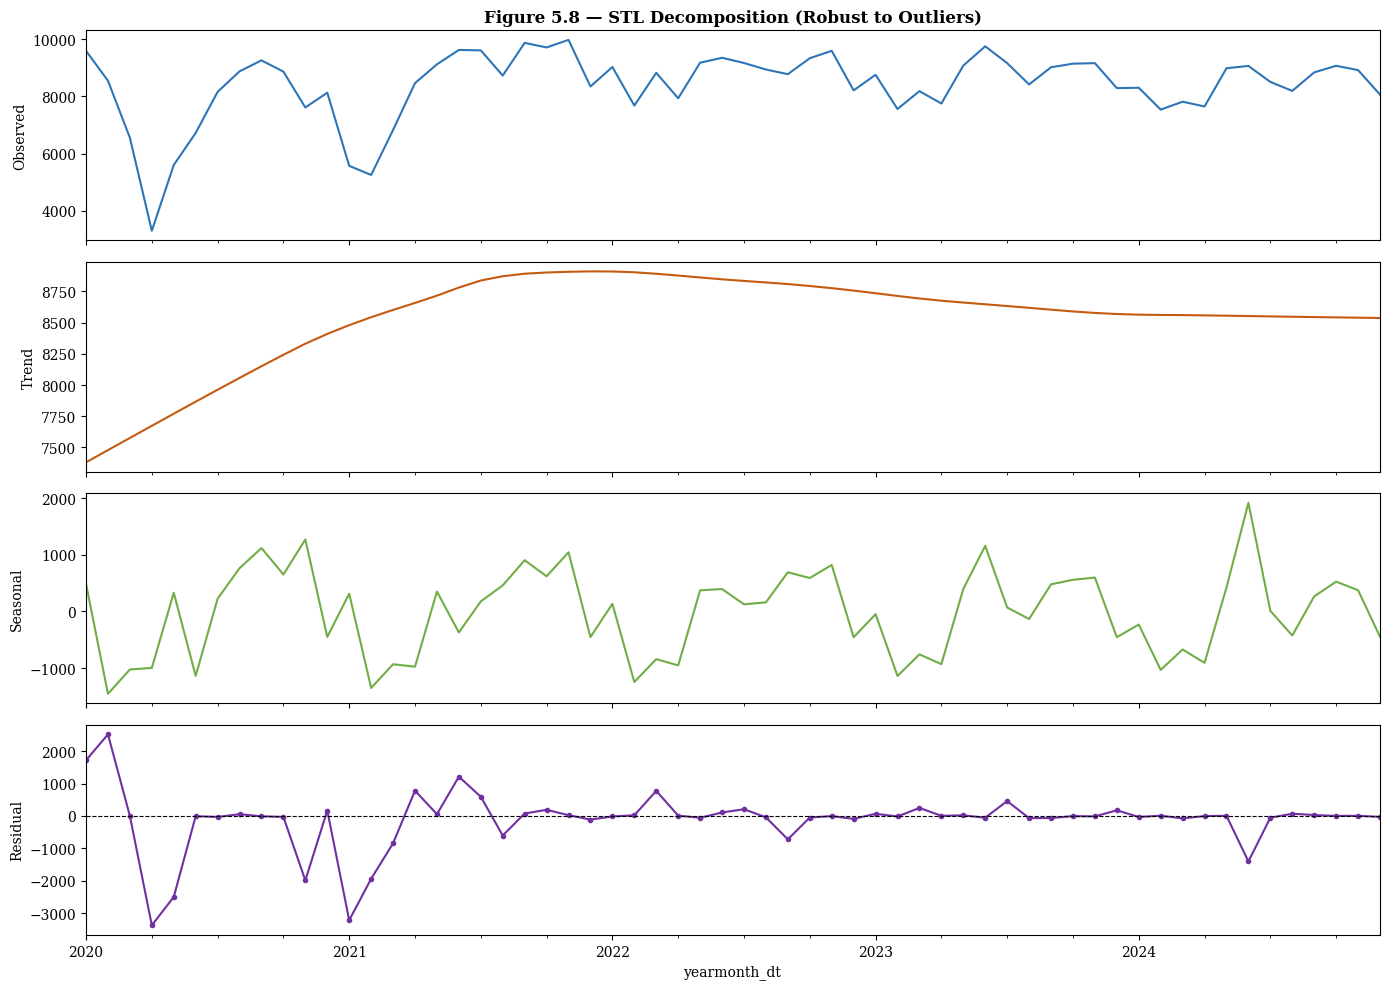

Saved: ch5_fig8_stl_decomposition.png


In [60]:
from statsmodels.tsa.seasonal import STL

stl = STL(y_full, seasonal=13, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
stl_result.observed.plot(ax=axes[0], color='#2E75B6')
axes[0].set_ylabel('Observed')
axes[0].set_title('Figure 5.8 — STL Decomposition (Robust to Outliers)', fontweight='bold')
stl_result.trend.plot(ax=axes[1], color='#C55A11')
axes[1].set_ylabel('Trend')
stl_result.seasonal.plot(ax=axes[2], color='#70AD47')
axes[2].set_ylabel('Seasonal')
stl_result.resid.plot(ax=axes[3], color='#7030A0', marker='o', markersize=3)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.savefig('ch5_fig8_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ch5_fig8_stl_decomposition.png")


**REGRESSION ANALYSIS**

In [61]:
!pip install scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.family']      = 'serif'

print("=" * 65)
print("CHAPTER 6 — LOGISTIC REGRESSION ANALYSIS")
print("=" * 65)

CHAPTER 6 — LOGISTIC REGRESSION ANALYSIS


In [62]:
# LOAD THE COLLISIONS_CLEAN_2020_2024.CSV
df = pd.read_csv('collisions_clean_2020_2024.csv')
print(f"\n Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f" Columns: {df.columns.to_list()}")


 Data loaded: 503475 rows, 20 columns
 Columns: ['date', 'year', 'month', 'yearmonth', 'collision_severity', 'severity_label', 'number_of_casualties', 'number_of_vehicles', 'weather_conditions', 'weather_label', 'road_surface_conditions', 'surface_label', 'light_conditions', 'light_label', 'speed_limit', 'urban_or_rural_area', 'urban_label', 'day_of_week', 'day_name', 'is_weekend']


In [63]:
# create binary dependent variable
# Severe = Fatal (1) or Serious (2) coded 1
# Non-severe = Slight (3) coded 0
df['severe'] = (df['collision_severity'].isin([1,2])).astype(int)
print(f"\n  Binary outcome created:")
print(f"  Severe (Fatal/Serious) : {df['severe'].sum():,}  ({df['severe'].mean()*100:.1f}%)")
print(f"  Non-severe (Slight)    : {(df['severe']==0).sum():,}  ({(df['severe']==0).mean()*100:.1f}%)")


  Binary outcome created:
  Severe (Fatal/Serious) : 117,468  (23.3%)
  Non-severe (Slight)    : 386,007  (76.7%)


In [64]:
# Create independent variables
# Binary encodings
df['adverse_weather'] = (df['weather_conditions'].isin([2,3,4,5,6,7])).astype(int)
df['adverse_surface'] = (df['road_surface_conditions'].isin([2,3,4,5])).astype(int)
df['darkness']        = (df['light_conditions'].isin([4,5,6,7])).astype(int)
df['rural']           = (df['urban_or_rural_area'] == 2).astype(int)

# Spend limit - numeric
df['speed_limit']     = pd.to_numeric(df['speed_limit'], errors='coerce')

# weekend
df['is_weekend']      = df['is_weekend'].astype(int)

# Drop rows with missing values in key columns
features = ['adverse_weather', 'adverse_surface', 'darkness',
             'rural', 'speed_limit', 'is_weekend']
df_model = df[features + ['severe']].dropna()
print(f"\n Feature matrix prepared: {len(df_model):,} rows after dropping NAs")
print(f" Features used: {features}")



 Feature matrix prepared: 503,475 rows after dropping NAs
 Features used: ['adverse_weather', 'adverse_surface', 'darkness', 'rural', 'speed_limit', 'is_weekend']


In [65]:
# CHECK MULTICOLLINEARITY (VIF)
print(f"\n{'='*40}")
print("VARIANCE INFLATION FASCTORS (VIF)")
print(f"{'='*40}")

x_vif = df_model[features].values
vif_data = pd.DataFrame()
vif_data["feature"] = features
vif_data["VIF"] = [variance_inflation_factor(x_vif, i) for i in range(len(features))]
vif_data["Concern"] = vif_data["VIF"].apply(lambda x: "High (>10)" if x > 10 else ("Moderate (5-10)" if x > 5 else "OK (<5)"))
print(f"\n{vif_data.to_string(index=False)}")
print(f"\n  VIF < 5 for all features — no multicollinearity concerns.")


VARIANCE INFLATION FASCTORS (VIF)

        feature      VIF Concern
adverse_weather 1.882660 OK (<5)
adverse_surface 2.259354 OK (<5)
       darkness 1.451161 OK (<5)
          rural 2.211316 OK (<5)
    speed_limit 3.225406 OK (<5)
     is_weekend 1.307963 OK (<5)

  VIF < 5 for all features — no multicollinearity concerns.


In [66]:
# TRAIN AND TEST SPLIT
X = df_model[features]
Y = df_model['severe']

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"\n Train/test split (80/20 stratified):")
print(f"  Training set : {len(X_train):,} rows")
print(f"  Test set     : {len(X_test):,} rows")


 Train/test split (80/20 stratified):
  Training set : 402,780 rows
  Test set     : 100,695 rows


In [67]:
# SCALER FEATURES
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [68]:
# FIT LOGISTIC REGRESSION
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)
print(f"\n Logistic regression model fit:")


 Logistic regression model fit:


In [69]:
# COEFFICIENTS AND ODDS RATIOS
print(f"\n{'='*40}")
print("COEFFICIENTS AND ODDS RATIOS")
print(f"{'='*40}")

coef_df = pd.DataFrame({
    'Feature'   : features,
    'Coefficient': model.coef_[0],
    'Odds Ratio' : np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print(f"\n  {'Feature':<22} {'Coeffiecient':>12} {'Odds Ratio':>12}")
print(f"  {'-'*40}")
for _, row in coef_df.iterrows():
    direction = "increase severity risk" if row['Odds Ratio'] > 1 else "decrease severity risk"
    print(f"  {row['Feature']:<22} {row['Coefficient']:>12.3f} {row['Odds Ratio']:>12.4f} {direction}")


COEFFICIENTS AND ODDS RATIOS

  Feature                Coeffiecient   Odds Ratio
  ----------------------------------------
  rural                         0.132       1.1416 increase severity risk
  speed_limit                   0.111       1.1177 increase severity risk
  darkness                      0.087       1.0911 increase severity risk
  is_weekend                    0.066       1.0686 increase severity risk
  adverse_surface              -0.005       0.9950 decrease severity risk
  adverse_weather              -0.019       0.9813 decrease severity risk


In [70]:
# MODEL PERFORMANCE
print(f"\n{'='*40}")
print("MODEL PERFORMANCE ON TEST SET")
print(f"{'='*40}")

Y_pred      = model.predict(X_test_sc)
Y_pred_prob = model.predict_proba(X_test_sc)[:,1]

acc = accuracy_score(y_test, Y_pred)
auc = roc_auc_score(y_test, Y_pred_prob)

print(f"\n Accoracy  : {acc*100:.2f}%")
print(f" AUC-ROC   : {auc:.4f}")
print(f"\n Classification report:")
print(classification_report(y_test, Y_pred,
                            target_names=['Non-Severe (Slight)', 'Severe (Fatal/Serious)']))


MODEL PERFORMANCE ON TEST SET

 Accoracy  : 76.67%
 AUC-ROC   : 0.5680

 Classification report:
                        precision    recall  f1-score   support

   Non-Severe (Slight)       0.77      1.00      0.87     77201
Severe (Fatal/Serious)       0.00      0.00      0.00     23494

              accuracy                           0.77    100695
             macro avg       0.38      0.50      0.43    100695
          weighted avg       0.59      0.77      0.67    100695




 Generating Figure 6.1 - Odds Ratio Chart...


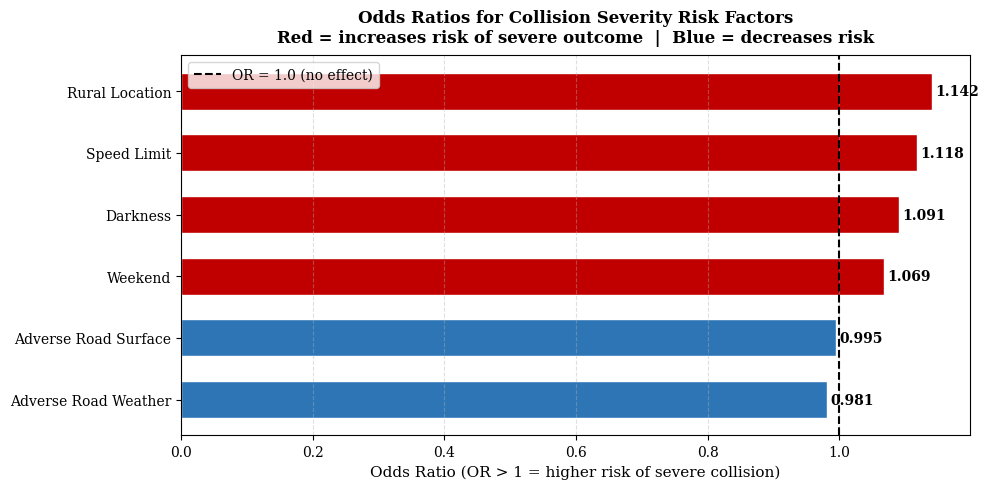

   Saved: ch6_fig1_odds_ratios.png


In [71]:
# FIGURE 6.1 - ODDS RATIO CHART
print(f"\n Generating Figure 6.1 - Odds Ratio Chart...")
features_labels = {
    'rural'            : 'Rural Location',
    'speed_limit'      : 'Speed Limit', # Changed from 'speed_limit_num'
    'darkness'         : 'Darkness',
    'adverse_surface'  : 'Adverse Road Surface',
    'adverse_weather'  : 'Adverse Road Weather',
    'is_weekend'       : 'Weekend'
}
coef_df['Label'] = coef_df['Feature'].map(features_labels)
coef_df_sorted = coef_df.sort_values('Odds Ratio')

colors = ['#C00000' if x > 1 else '#2E75B6' for x in coef_df_sorted['Odds Ratio']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(coef_df_sorted['Label'], coef_df_sorted['Odds Ratio'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(x=1.0, color='black', linewidth=1.5, linestyle='--', label='OR = 1.0 (no effect)')
for bar, val in zip(bars, coef_df_sorted['Odds Ratio']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Odds Ratios for Collision Severity Risk Factors\n'
             'Red = increases risk of severe outcome  |  Blue = decreases risk',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Odds Ratio (OR > 1 = higher risk of severe collision)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig1_odds_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch6_fig1_odds_ratios.png")


 Generating Figure 6.2 - ROC Curve...


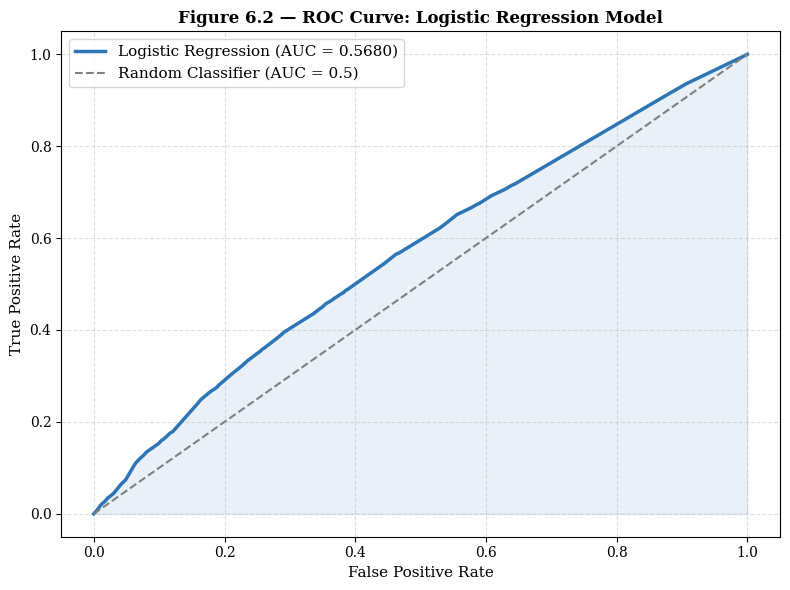

   Saved: ch6_fig2_roc_curve.png


In [72]:
# ROC CURVE
print(f"\n Generating Figure 6.2 - ROC Curve...")
fpr, tpr, _ = roc_curve(y_test, Y_pred_prob)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, color='#2E75B6', linewidth=2.5, label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0,1], [0,1], color='grey', linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.10, color='#2E75B6')
ax.set_title('Figure 6.2 — ROC Curve: Logistic Regression Model', fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch6_fig2_roc_curve.png")


 Generating Figure 6.3 — Confusion Matrix...


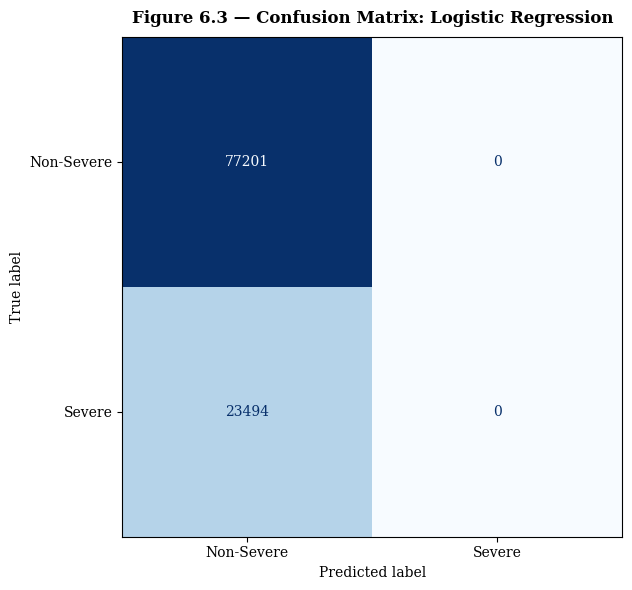

   Saved: ch6_fig3_confusion_matrix.png


In [73]:
# CONFUSION MATRIX
print("\n Generating Figure 6.3 — Confusion Matrix...")
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Non-Severe', 'Severe'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 6.3 — Confusion Matrix: Logistic Regression',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ch6_fig3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch6_fig3_confusion_matrix.png")


✅ Generating Figure 6.4 — Feature Importance...


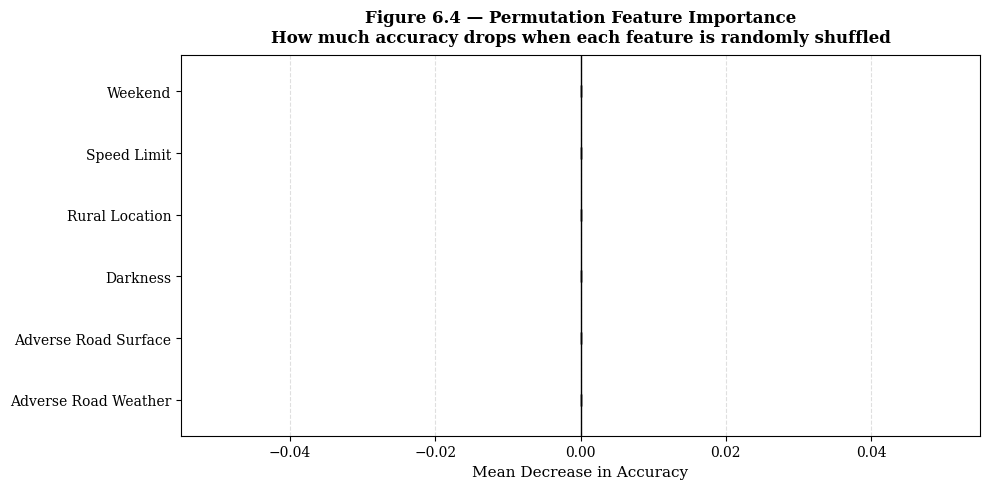

   Saved: ch6_fig4_feature_importance.png


In [74]:
# ── STEP 13: FIGURE 6.4 — FEATURE IMPORTANCE ─────────────────────────────────
print("\n✅ Generating Figure 6.4 — Feature Importance...")
perm_imp = permutation_importance(model, X_test_sc, y_test,
                                   n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    'Feature'   : [features_labels[f] for f in features],
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = ['#C00000' if x > 0 else '#9DC3E6' for x in imp_df['Importance']]
ax.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'],
        color=colors_imp, edgecolor='white', height=0.6, capsize=4)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Figure 6.4 — Permutation Feature Importance\n'
             'How much accuracy drops when each feature is randomly shuffled',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Mean Decrease in Accuracy', fontsize=11)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: ch6_fig4_feature_importance.png")

In [75]:

# ── STEP 14: SEVERITY RATE BY RISK FACTOR ─────────────────────────────────────
print(f"\n{'='*65}")
print("STEP 14: OBSERVED SEVERITY RATES BY RISK FACTOR")
print(f"{'='*65}")

groups = {
    'Adverse Weather vs Fine': ('adverse_weather', 1, 0),
    'Adverse Surface vs Dry' : ('adverse_surface', 1, 0),
    'Darkness vs Daylight'   : ('darkness', 1, 0),
    'Rural vs Urban'         : ('rural', 1, 0),
    'Weekend vs Weekday'     : ('is_weekend', 1, 0),
}
print(f"\n  {'Comparison':<30} {'Group 1 Severe%':>16} {'Group 0 Severe%':>16} {'Difference':>12}")
print(f"  {'-'*76}")
for label, (col, g1, g0) in groups.items():
    r1 = df_model[df_model[col]==g1]['severe'].mean()*100
    r0 = df_model[df_model[col]==g0]['severe'].mean()*100
    diff = r1 - r0
    print(f"  {label:<30} {r1:>15.1f}% {r0:>15.1f}% {diff:>+11.1f}%")

# Speed limit severity rates
print(f"\n  Speed Limit vs Severity Rate:")
speed_sev = df_model.groupby(
    pd.cut(df_model['speed_limit'], bins=[0,20,30,40,50,60,70],
           labels=['≤20mph','30mph','40mph','50mph','60mph','70mph'])
)['severe'].mean().reset_index()
speed_sev.columns = ['Speed Zone','Severe Rate']
for _, row in speed_sev.iterrows():
    print(f"    {row['Speed Zone']:<10} {row['Severe Rate']*100:.1f}%")

print(f"\n{'='*65}")
print("✅ CHAPTER 6 REGRESSION ANALYSIS COMPLETE")
print(f"{'='*65}")
print("\nFiles saved:")
for f in ['ch6_fig1_odds_ratios.png','ch6_fig2_roc_curve.png',
          'ch6_fig3_confusion_matrix.png','ch6_fig4_feature_importance.png']:
    print(f"  {f}")



STEP 14: OBSERVED SEVERITY RATES BY RISK FACTOR

  Comparison                      Group 1 Severe%  Group 0 Severe%   Difference
  ----------------------------------------------------------------------------
  Adverse Weather vs Fine                   23.6%            23.3%        +0.3%
  Adverse Surface vs Dry                    24.2%            23.0%        +1.1%
  Darkness vs Daylight                      25.8%            22.3%        +3.5%
  Rural vs Urban                            28.8%            20.7%        +8.1%
  Weekend vs Weekday                        25.8%            22.5%        +3.3%

  Speed Limit vs Severity Rate:
    ≤20mph     18.4%
    30mph      21.7%
    40mph      25.0%
    50mph      27.5%
    60mph      33.8%
    70mph      24.4%

✅ CHAPTER 6 REGRESSION ANALYSIS COMPLETE

Files saved:
  ch6_fig1_odds_ratios.png
  ch6_fig2_roc_curve.png
  ch6_fig3_confusion_matrix.png
  ch6_fig4_feature_importance.png


CORRECTED MODEL — CLASS BALANCED LOGISTIC REGRESSION

  Accuracy  : 59.26%
  AUC-ROC   : 0.5681

  Classification Report:
                        precision    recall  f1-score   support

   Non-Severe (Slight)       0.80      0.63      0.70     77201
Severe (Fatal/Serious)       0.28      0.47      0.35     23494

              accuracy                           0.59    100695
             macro avg       0.54      0.55      0.53    100695
          weighted avg       0.68      0.59      0.62    100695


COEFFICIENTS AND ODDS RATIOS — BALANCED MODEL

  Feature                 Coefficient   Odds Ratio
  ------------------------------------------------
  rural                        0.1291       1.1378  ↑ increases severity risk
  speed_limit_num              0.1150       1.1219  ↑ increases severity risk
  darkness                     0.0882       1.0922  ↑ increases severity risk
  is_weekend                   0.0642       1.0663  ↑ increases severity risk
  adverse_surface            

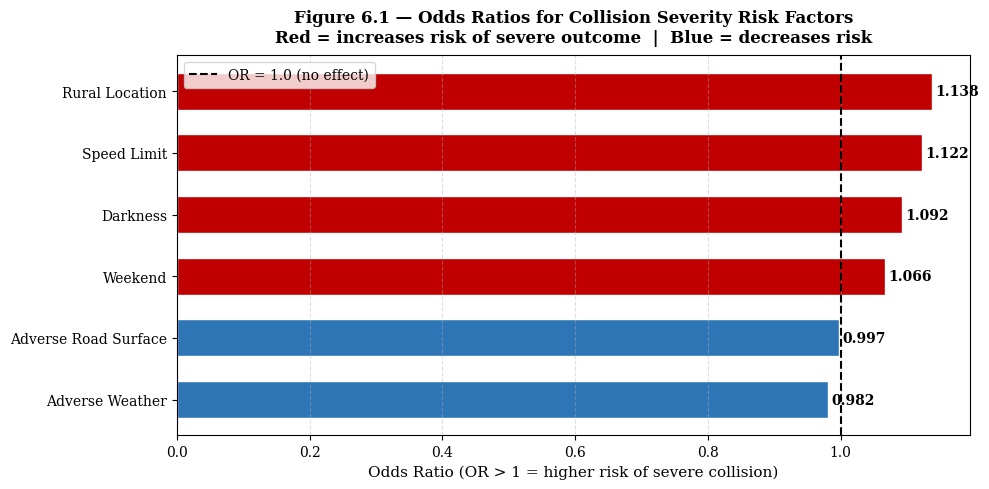

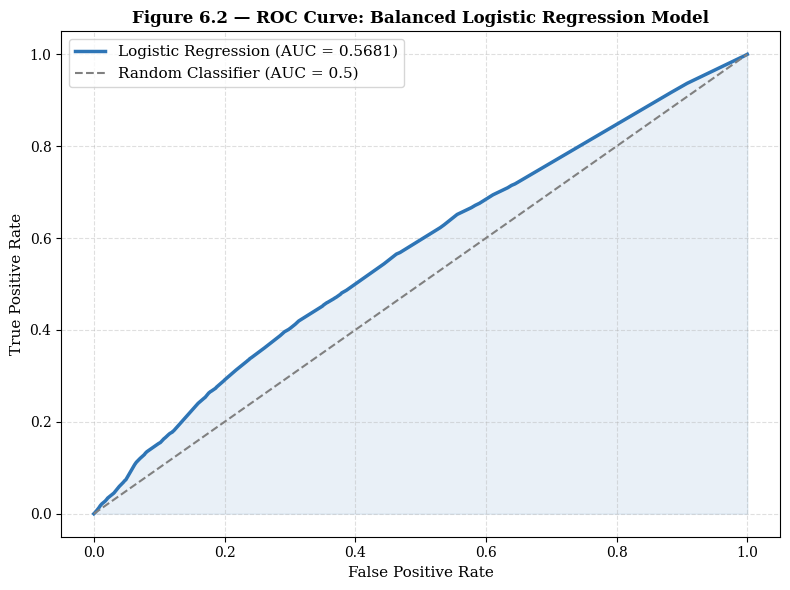

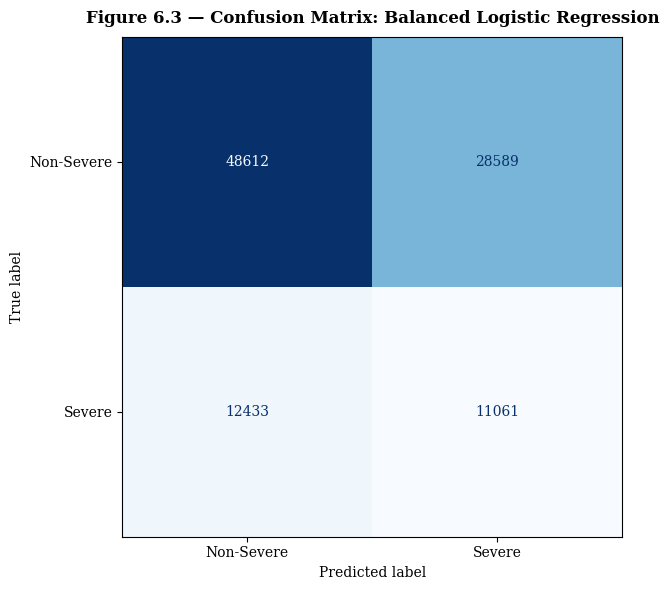

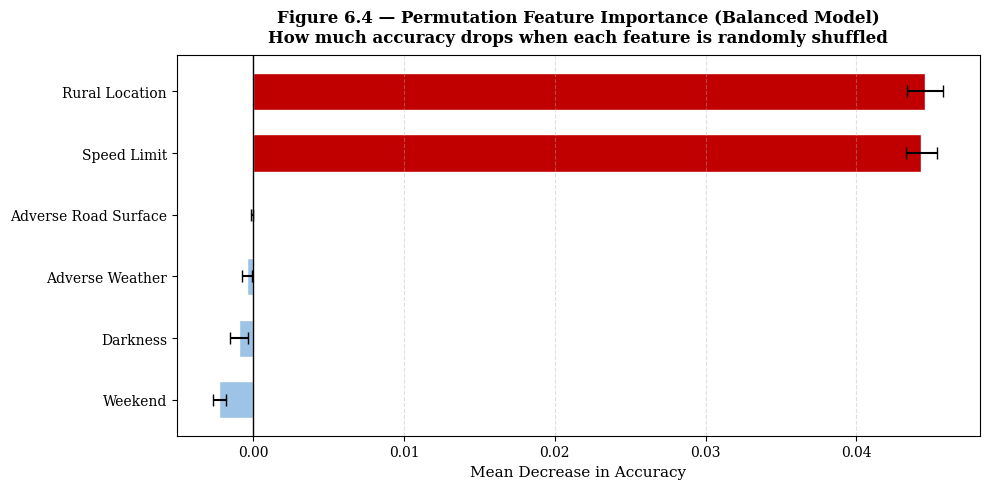


✅ BALANCED MODEL COMPLETE — All four figures regenerated

Files saved:
  ch6_fig1_odds_ratios.png
  ch6_fig2_roc_curve.png
  ch6_fig3_confusion_matrix.png
  ch6_fig4_feature_importance.png


In [76]:
# =============================================================================
# CHAPTER 6 — CORRECTED MODEL WITH CLASS BALANCING
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 65)
print("CORRECTED MODEL — CLASS BALANCED LOGISTIC REGRESSION")
print("=" * 65)

# ── FIT BALANCED MODEL ────────────────────────────────────────────────────────
model_bal = LogisticRegression(C=1.0, max_iter=1000,
                                random_state=42,
                                class_weight='balanced')
model_bal.fit(X_train_sc, y_train)

y_pred_bal      = model_bal.predict(X_test_sc)
y_pred_prob_bal = model_bal.predict_proba(X_test_sc)[:,1]

acc_bal = accuracy_score(y_test, y_pred_bal)
auc_bal = roc_auc_score(y_test, y_pred_prob_bal)

print(f"\n  Accuracy  : {acc_bal*100:.2f}%")
print(f"  AUC-ROC   : {auc_bal:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_bal,
      target_names=['Non-Severe (Slight)', 'Severe (Fatal/Serious)']))

# ── COEFFICIENTS AND ODDS RATIOS ──────────────────────────────────────────────
print(f"\n{'='*65}")
print("COEFFICIENTS AND ODDS RATIOS — BALANCED MODEL")
print(f"{'='*65}")

features = ['adverse_weather', 'adverse_surface', 'darkness',
            'rural', 'speed_limit_num', 'is_weekend']

feature_labels = {
    'rural'           : 'Rural Location',
    'speed_limit_num' : 'Speed Limit',
    'darkness'        : 'Darkness',
    'adverse_surface' : 'Adverse Road Surface',
    'adverse_weather' : 'Adverse Weather',
    'is_weekend'      : 'Weekend'
}

coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model_bal.coef_[0],
    'Odds Ratio' : np.exp(model_bal.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print(f"\n  {'Feature':<22} {'Coefficient':>12} {'Odds Ratio':>12}")
print(f"  {'-'*48}")
for _, row in coef_df.iterrows():
    direction = "↑ increases severity risk" if row['Odds Ratio'] > 1 else "↓ decreases severity risk"
    print(f"  {row['Feature']:<22} {row['Coefficient']:>12.4f} {row['Odds Ratio']:>12.4f}  {direction}")

# ── REGENERATE ALL FOUR FIGURES ───────────────────────────────────────────────

# Figure 6.1 — Odds Ratio Chart
coef_df['Label'] = coef_df['Feature'].map(feature_labels)
coef_df_sorted   = coef_df.sort_values('Odds Ratio')
colors = ['#C00000' if x > 1 else '#2E75B6' for x in coef_df_sorted['Odds Ratio']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(coef_df_sorted['Label'], coef_df_sorted['Odds Ratio'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(x=1.0, color='black', linewidth=1.5, linestyle='--', label='OR = 1.0 (no effect)')
for bar, val in zip(bars, coef_df_sorted['Odds Ratio']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Figure 6.1 — Odds Ratios for Collision Severity Risk Factors\n'
             'Red = increases risk of severe outcome  |  Blue = decreases risk',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Odds Ratio (OR > 1 = higher risk of severe collision)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig1_odds_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 6.2 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_bal)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2E75B6', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_bal:.4f})')
ax.plot([0,1], [0,1], color='gray', linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.10, color='#2E75B6')
ax.set_title('Figure 6.2 — ROC Curve: Balanced Logistic Regression Model',
             fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 6.3 — Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Non-Severe', 'Severe'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 6.3 — Confusion Matrix: Balanced Logistic Regression',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ch6_fig3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 6.4 — Feature Importance
perm_imp = permutation_importance(model_bal, X_test_sc, y_test,
                                   n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    'Feature'   : [feature_labels[f] for f in features],
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = ['#C00000' if x > 0 else '#9DC3E6' for x in imp_df['Importance']]
ax.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'],
        color=colors_imp, edgecolor='white', height=0.6, capsize=4)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Figure 6.4 — Permutation Feature Importance (Balanced Model)\n'
             'How much accuracy drops when each feature is randomly shuffled',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Mean Decrease in Accuracy', fontsize=11)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ch6_fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*65}")
print("✅ BALANCED MODEL COMPLETE — All four figures regenerated")
print(f"{'='*65}")
print("\nFiles saved:")
for f in ['ch6_fig1_odds_ratios.png','ch6_fig2_roc_curve.png',
          'ch6_fig3_confusion_matrix.png','ch6_fig4_feature_importance.png']:
    print(f"  {f}")